In [1]:
#| default_exp _trainer

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
#| export
import torch
import matplotlib.pyplot as plt
from dreamer4._core import build_tiny_pinpad_dataset, make_tiny_dataloader, build_pinpad_datasets_for_trainers
from dreamer4.dreamer4 import VideoTokenizer, DynamicsWorldModel
from dreamer4.trainers import VideoTokenizerTrainer, SimTrainer, cycle, BehaviorCloneTrainer
import random

/home/j/workspace/dreamer4/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pads {'2', '1', '3'} target ('1', '2', '3')

pads {'2', '1', '3'} target ('1', '2', '3')



In [4]:
CPU = False
neps = 1
device = 'cuda' if not CPU else 'cpu'
dataset, env = build_tiny_pinpad_dataset(device=device, episode_length=100, n=neps)

pads {'2', '1', '3'} target ('1', '2', '3')

Built tiny PinPad dataset with 1 videos of shape torch.Size([3, 100, 64, 64]) - (c, t, h, w). Success rate 100.0%


In [5]:
# 1) Build datasets
tok_ds, bc_ds, env = build_pinpad_datasets_for_trainers(
    n_episodes=200,
    episode_length=100,
    tok_window=16,
    device='cpu',
    use_motion_planner=True
)


pads {'2', '1', '3'} target ('1', '2', '3')

pads {'2', '1', '3'} target ('1', '2', '3')



In [6]:
import torch
import matplotlib.pyplot as plt

def get_video_from_sample(sample):
    """Return a (C,T,H,W) or (T,C,H,W) tensor from dict/tuple/tensor samples."""
    if isinstance(sample, dict):
        v = sample.get("video", next((x for x in sample.values() if torch.is_tensor(x)), None))
    elif isinstance(sample, (list, tuple)):
        # common case: TensorDataset(videos) -> (video,)
        v = sample[0]
    else:
        v = sample
    if not torch.is_tensor(v):
        raise TypeError(f"Couldn't find a tensor video in sample of type {type(sample)}")
    return v

def canonicalize_cthw(v):
    """Ensure (C,T,H,W); convert dtype/range for visibility."""
    if v.ndim != 4:
        raise ValueError(f"Expected 4D video, got shape {tuple(v.shape)}")
    # If first dim isn't channels, assume (T,C,H,W) and permute
    if v.shape[0] not in (1,3):
        v = v.permute(1,0,2,3).contiguous()  # (T,C,H,W) -> (C,T,H,W)
    # Make float in [0,1] for viewing
    if v.dtype.is_floating_point:
        # if it looks zero-centered, de-normalize (heuristic)
        if v.min() < 0:
            v = (v * 0.5) + 0.5
        v = v.clamp(0,1)
    else:
        v = v.float() / 255.0
    return v

def peek_video(sample, title="sample", t=0):
    v = get_video_from_sample(sample)
    print(f"{title} raw:", v.shape, v.dtype, "min/max:", float(v.min()), float(v.max()))
    v = canonicalize_cthw(v)
    C,T,H,W = v.shape
    img = v[:, min(t,T-1)].permute(1,2,0).cpu().numpy()
    print(f"{title} canonical:", v.shape, v.dtype, "min/max:", float(v.min()), float(v.max()))
    plt.figure(figsize=(3,3)); plt.imshow(img); plt.title(f"{title} t={min(t,T-1)}"); plt.axis("off"); plt.show()
    return v


tok_ds[0] raw: torch.Size([3, 16, 64, 64]) torch.float32 min/max: -1.0 1.0
tok_ds[0] canonical: torch.Size([3, 16, 64, 64]) torch.float32 min/max: 0.0 1.0


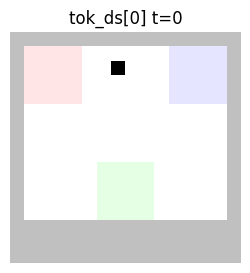

bc_ds[0] raw: torch.Size([3, 16, 64, 64]) torch.float32 min/max: -1.0 1.0
bc_ds[0] canonical: torch.Size([3, 16, 64, 64]) torch.float32 min/max: 0.0 1.0


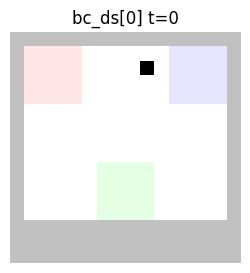

In [7]:

# Use on both datasets:
v_tok = peek_video(tok_ds[0], title="tok_ds[0]")
v_bc  = peek_video(bc_ds[0],  title="bc_ds[0]")


In [8]:
## DEBUG MEMORY ##

import torch
import gc
import psutil

def format_bytes(size):
    power = 2**10
    n = 0
    power_labels = {0 : '', 1: 'K', 2: 'M', 3: 'G', 4: 'T'}
    while size > power:
        size /= power
        n += 1
    return f"{size:.2f} {power_labels[n]}B"

def audit_gpu_memory():
    """
    Prints a breakdown of what is currently on the GPU.
    Safely handles torch.compile Symbolic/FakeTensors.
    """
    if not torch.cuda.is_available():
        print("CUDA is not available.")
        return

    print("\n--- GPU MEMORY AUDIT ---")
    
    # 1. Global Stats
    try:
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        print(f"Total Allocated (Tensors): {format_bytes(allocated)}")
        print(f"Total Reserved (Caching Allocator): {format_bytes(reserved)}")
    except Exception as e:
        print(f"Could not get global stats: {e}")
    
    # 2. Iterate through all Python objects to find GPU Tensors
    tensors = []
    for obj in gc.get_objects():
        try:
            # Check if it's a tensor
            if torch.is_tensor(obj) or (hasattr(obj, 'data') and torch.is_tensor(obj.data)):
                # FILTER: Skip Symbolic/Fake tensors (used by torch.compile)
                # If it doesn't have a concrete device index, it's not real VRAM.
                if obj.device.type != 'cuda':
                    continue
                
                # FILTER: Skip if we can't get a concrete integer size
                # (Symbolic tensors return SymInts for nelement, which crash int() conversion)
                if hasattr(obj, "is_meta") and obj.is_meta:
                    continue
                    
                tensors.append(obj)
        except Exception:
            # If touching the object crashes (common with some internal PyTorch objects), skip it
            pass

    print(f"\nFound {len(tensors)} discrete tensor objects on GPU.")
    
    # 3. Group by Shape/Size to identify patterns
    tensor_stats = {}
    for t in tensors:
        try:
            # Safely get size. If this crashes or returns a symbol, skip.
            numel = t.nelement()
            elem_size = t.element_size()
            
            # Force conversion to python int to catch symbols early
            total_bytes = int(numel) * int(elem_size)
            
            shape_str = str(tuple(t.shape))
            if shape_str not in tensor_stats:
                tensor_stats[shape_str] = {"count": 0, "size": 0}
            
            tensor_stats[shape_str]["count"] += 1
            tensor_stats[shape_str]["size"] += total_bytes
        except Exception:
            continue

    # 4. Print the "Top 5" Memory Hogs
    print("\nTOP 5 TENSOR GROUPS BY MEMORY:")
    
    # Now sorting is safe because 'size' is guaranteed to be a real python int
    sorted_stats = sorted(tensor_stats.items(), key=lambda x: x[1]['size'], reverse=True)[:5]
    
    for shape, stats in sorted_stats:
        print(f"  Shape {shape}: {stats['count']} tensors | Total Size: {format_bytes(stats['size'])}")

    print("-" * 30)

# Create tokenizer and dynamics models and associated training

Using device: cuda
Dataset ready. Samples: 17000
Overwriting latent parameter sizes for simplified tokenizer.

Starting Sanity Train (500 steps)...
Step 0: Loss = 2.7569
Step 10: Loss = 0.1210
Step 20: Loss = 0.0876
Step 30: Loss = 0.0625
Step 40: Loss = 0.0499
Step 50: Loss = 0.0396
Step 60: Loss = 0.0288
Step 70: Loss = 0.0225
Step 80: Loss = 0.0173
Step 90: Loss = 0.0168
Step 100: Loss = 0.0126
Step 110: Loss = 0.0110
Step 120: Loss = 0.0091
Step 130: Loss = 0.0085
Step 140: Loss = 0.0081
Step 150: Loss = 0.0068
Step 160: Loss = 0.0062
Step 170: Loss = 0.0054
Step 180: Loss = 0.0055
Step 190: Loss = 0.0045
Step 200: Loss = 0.0040
Step 210: Loss = 0.0039
Step 220: Loss = 0.0036
Step 230: Loss = 0.0024
Step 240: Loss = 0.0030
Step 250: Loss = 0.0024
Step 260: Loss = 0.0030
Step 270: Loss = 0.0025
Step 280: Loss = 0.0026
Step 290: Loss = 0.0018
Step 300: Loss = 0.0017
Step 310: Loss = 0.0022
Step 320: Loss = 0.0015
Step 330: Loss = 0.0016
Step 340: Loss = 0.0018
Step 350: Loss = 0.0017

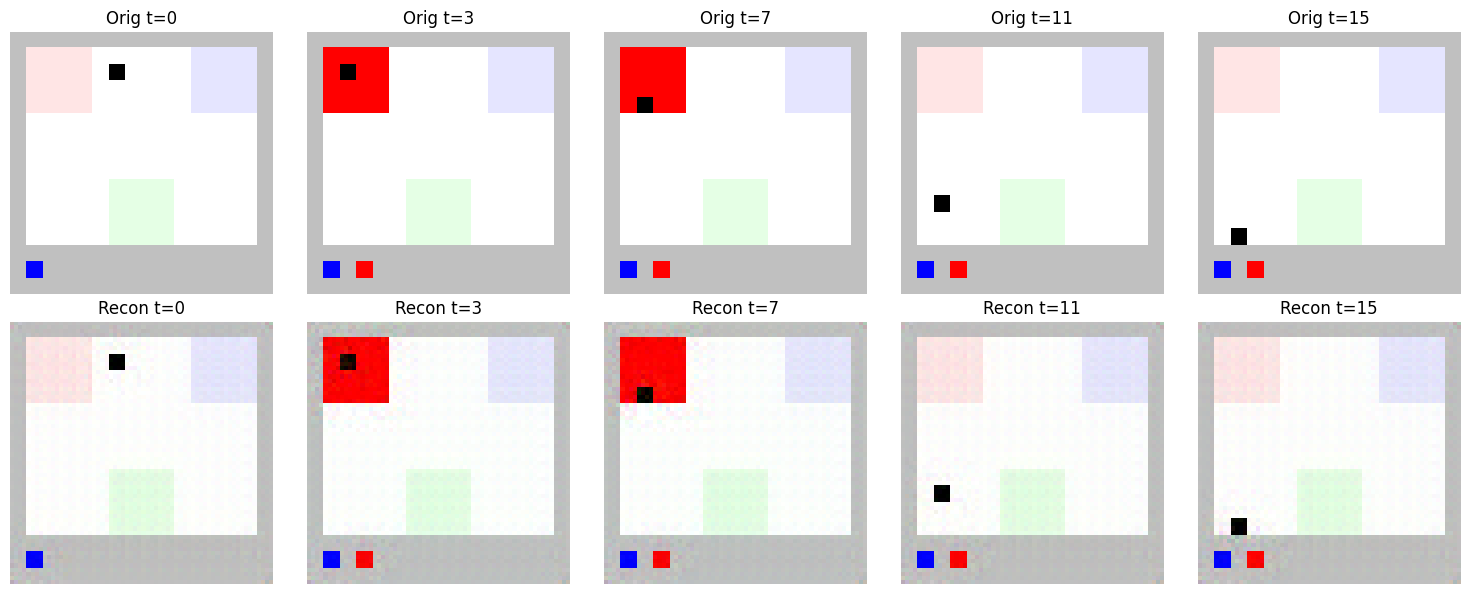

In [9]:
dim, dim_latent, num_latent_tokens, num_spatial_tokens = 256, 256, 256, 256
d=2
encoder_depth, decoder_depth, dynamics_depth = d, d, d
time_block_every=d
lpips_loss_weight=0.2 # default 
decor_auxx_loss_weight=0.1 # default
use_time_rnn = False # don't include an RNN

batch_size = 8 #16
num_train_steps=1000

accelerate_kwargs={"mixed_precision": "bf16"}
token_uses_time_block = True; time_block_every = d if token_uses_time_block else 1000

if SIMPLE_TOKENIZER:=False:
    # Tokenizer debug config suggested by gemini3 pro
    tk = VideoTokenizer(
        dim=dim,                  # Massive increase from 64/128 (Better feature capture)
        dim_latent=dim_latent,           # Larger bottleneck capacity
        patch_size=4,             # Keep this small
        num_latent_tokens=num_latent_tokens,    # CRITICAL: Keep this matched to patches (16x16)
        encoder_depth=encoder_depth,          # Deeper is better for reasoning about features
        decoder_depth=decoder_depth,
        time_block_every=time_block_every,       # More temporal blocks for video
        lpips_loss_weight=lpips_loss_weight,    # Strong perceptual signal
        per_image_patch_mask_prob=(0.0, 0.0),  # No masking during debugging
        decor_auxx_loss_weight = decor_auxx_loss_weight,
    ).to(device)

    from torch.optim import AdamW
    # 2) Train tokenizer (VideoTokenizerTrainer expects a TensorDataset and uses [0])
    tok_tr = VideoTokenizerTrainer(tk, tok_ds, batch_size=batch_size, num_train_steps=num_train_steps,
                                weight_decay=0,
                                optim_klass=AdamW,
                                #    learning_rate=1e-3,
                                accelerate_kwargs=accelerate_kwargs,)
    tok_tr(num_train_step=1000)
else:
    from dreamer4._core import DataLoader
    from torch.optim import AdamW
    import numpy as np

    n_train_steps=500
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # A. Build Dataset

    from dreamer4._tokenizer import SimpleConvTokenizer
    dl = DataLoader(tok_ds, batch_size=16, shuffle=True)
    print(f"Dataset ready. Samples: {len(tok_ds)}")

    # B. Initialize Model
    tk = SimpleConvTokenizer(
        dim=64, 
        dim_latent=dim_latent, 
        down_steps=2,  # 16 tokens (4x4 grid)
        image_size=64,
    ).to(device)

    print(f"Overwriting latent parameter sizes for simplified tokenizer.")
    num_spatial_tokens = tk.num_latent_tokens
    num_latent_tokens = tk.num_latent_tokens

    optimizer = AdamW(tk.parameters(), lr=1e-3)

    # C. Quick Training Loop (Proof of Life)
    print(f"\nStarting Sanity Train ({n_train_steps} steps)...")
    tk.train()

    losses = []

    iterator = iter(dl)
    for i in range(n_train_steps):
        try:
            batch = next(iterator)
        except StopIteration:
            iterator = iter(dl)
            batch = next(iterator)
            
        video = batch.to(device) # (B, C, T, H, W)
        
        loss = tk(video)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        if i % 10 == 0:
            print(f"Step {i}: Loss = {loss.item():.4f}")

    # D. Visualization
    print("\nVisualizing Result...")
    tk.eval()

    # Get a fresh sample
    sample = next(iter(dl)).to(device)
    with torch.no_grad():
        latents = tk.encode(sample)
        recon = tk.decode(latents)

    # Pick first batch item, 5 evenly spaced frames
    idx = 0
    t_indices = np.linspace(0, sample.shape[2]-1, 5, dtype=int)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    for i, t in enumerate(t_indices):
        # Original (Top)
        orig = sample[idx, :, t].permute(1,2,0).cpu().numpy()
        orig = (orig + 1) / 2 # [-1, 1] -> [0, 1]
        
        # Recon (Bottom)
        rec = recon[idx, :, t].permute(1,2,0).cpu().numpy()
        rec = (rec + 1) / 2
        
        axes[0, i].imshow(np.clip(orig, 0, 1))
        axes[0, i].set_title(f"Orig t={t}")
        axes[0, i].axis('off')
        
        axes[1, i].imshow(np.clip(rec, 0, 1))
        axes[1, i].set_title(f"Recon t={t}")
        axes[1, i].axis('off')
        
        # Check specific pixel ranges
        if i == 0:
            print(f"Recon Range: min={rec.min():.2f}, max={rec.max():.2f}")

    plt.tight_layout()
    plt.show()

# dynamics = DynamicsWorldModel(
#     video_tokenizer=tk,
#     dim=dim,
#     dim_latent=dim_latent,
#     max_steps=64,
#     num_tasks=1,
#     num_latent_tokens=num_latent_tokens,          # match tokenizer
#     num_spatial_tokens=num_spatial_tokens,         # was 2 (too tiny), then 8 not big enough to track movement
#     depth=dynamics_depth,                      # was default 4
#     time_block_every=time_block_every,           # was 4
#     pred_orig_latent=True,
#     num_discrete_actions=env.action_space.n,
#     attn_dim_head=32,
#     prob_no_shortcut_train=0.4,   # give shortcut some presence
#     num_residual_streams=1,
#     use_time_rnn = use_time_rnn,
# ).to(device)

# # 3) Train world model with BC (BehaviorCloneTrainer expects a dict batch and calls model(**batch))
# bc_tr = BehaviorCloneTrainer(dynamics, bc_ds, batch_size=batch_size, num_train_steps=num_train_steps,
#                                                             accelerate_kwargs=accelerate_kwargs,)


In [10]:
# Check Latent Statistics
sample = next(iter(dl)).to(device) # (B, C, T, H, W)
with torch.no_grad():
    latents = tk.encode(sample)
    
print(f"Latent Mean: {latents.mean().item():.4f}")
print(f"Latent Std:  {latents.std().item():.4f}")
print(f"Latent Min:  {latents.min().item():.4f}")
print(f"Latent Max:  {latents.max().item():.4f}")

Latent Mean: -0.0003
Latent Std:  0.9978
Latent Min:  -3.7638
Latent Max:  3.8722


--- Stats for Frame 0 ---
Original range:      min=0.00, max=1.00
Reconstructed range: min=0.00, max=1.00


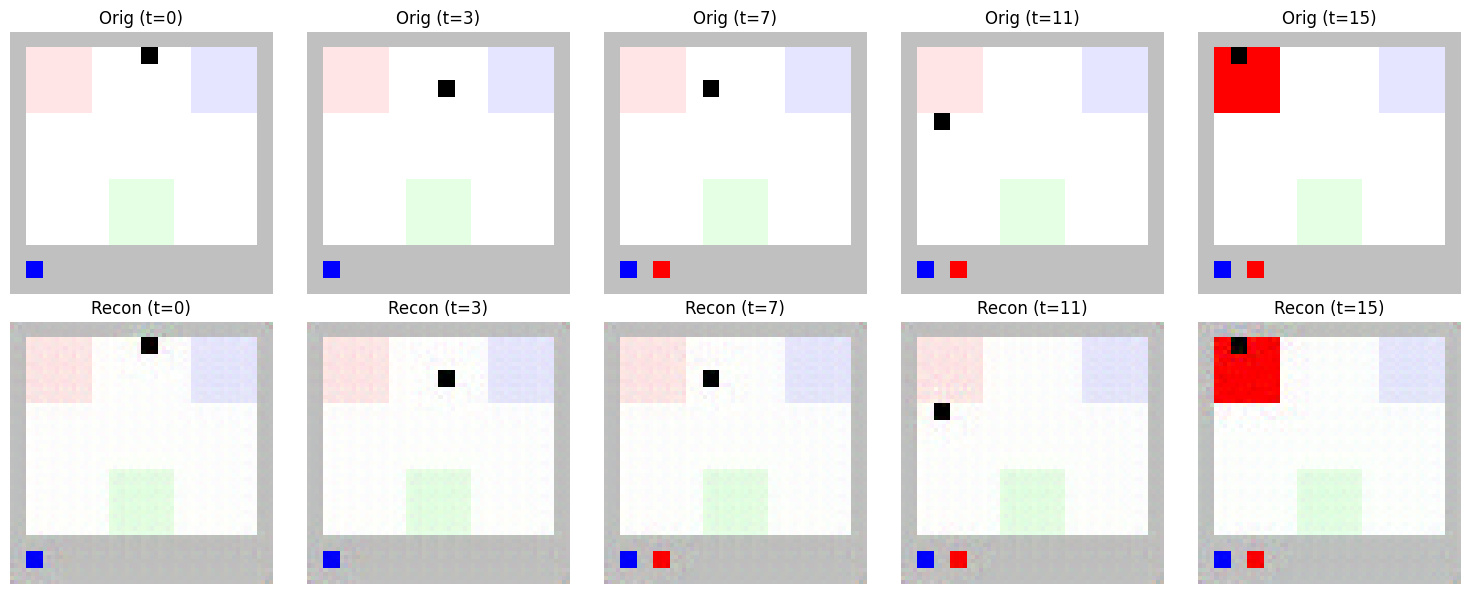

In [11]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def check_tokenizer_fidelity(tokenizer, video, num_frames=5):
    """
    Visualizes multiple frames to check reconstruction quality across time.
    Top Row: Original | Bottom Row: Reconstruction
    """
    device = next(tokenizer.parameters()).device
    video = video.to(device)
    
    # FIX: Ensure (1, C, T, H, W)
    if video.ndim == 4:
        video = video.unsqueeze(0)
        
    tokenizer.eval()
    with torch.no_grad():
        # Encode
        latents = tokenizer.tokenize(video) # (1, T, N, D)
        # Decode
        recon = tokenizer.decode(latents, height=64, width=64)
    tokenizer.train()

    # Calculate indices for frames to show (evenly spaced)
    T = video.shape[2]
    # If video is shorter than num_frames, just show all of them
    if T <= num_frames:
        indices = list(range(T))
    else:
        indices = np.linspace(0, T-1, num_frames, dtype=int)
    
    # Create grid: 2 Rows, N Columns
    fig, axes = plt.subplots(2, len(indices), figsize=(3 * len(indices), 6))
    
    # Handle single frame case (matplotlib axes subtleties)
    if len(indices) == 1:
        axes = axes.reshape(2, 1)

    print(f"--- Stats for Frame {indices[0]} ---")
    
    for i, t_idx in enumerate(indices):
        # 1. Process Original
        # Un-normalize: [-1, 1] -> [0, 1]
        orig_img = (video[0, :, t_idx] + 1) / 2
        orig_img = orig_img.permute(1,2,0).cpu().clamp(0,1).numpy()
        
        # 2. Process Reconstruction
        recon_img = (recon[0, :, t_idx] + 1) / 2
        recon_img = recon_img.permute(1,2,0).cpu().clamp(0,1).numpy()
        
        # Print stats only for the first frame to keep logs clean
        if i == 0:
            print(f"Original range:      min={orig_img.min():.2f}, max={orig_img.max():.2f}")
            print(f"Reconstructed range: min={recon_img.min():.2f}, max={recon_img.max():.2f}")

        # 3. Plot Original (Top Row)
        axes[0, i].imshow(orig_img)
        axes[0, i].set_title(f"Orig (t={t_idx})")
        axes[0, i].axis('off')
        
        # 4. Plot Reconstruction (Bottom Row)
        axes[1, i].imshow(recon_img)
        axes[1, i].set_title(f"Recon (t={t_idx})")
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Usage:
# sample = bc_ds[0]
# video = sample["video"].to(tk.device)   
# check_tokenizer_fidelity(tk, video)

sample = bc_ds[random.randint(0, len(bc_ds)-1)]
video = sample["video"].to(tk.device)   
check_tokenizer_fidelity(tk, video)  # use BC video for more variety

In [12]:
video[:,0,...].min(), video[:,0,...].max()

(tensor(-1., device='cuda:0'), tensor(1., device='cuda:0'))

In [13]:
## Tokenizer Training Loop ##

# first set lpips loss to 0
# tk.lpips_loss_weight = 0.0

# losses = []
# if True:
#     tok_tr.train()
#     # bc_tr.train()
#     print(f'{tk.training=}')
    
#     # while tok_tr.total_steps < 1e3:
#     for _ in range(100):
#         sample = bc_ds[random.randint(0, len(bc_ds)-1)]
#         video = sample["video"].to(tk.device)   
#         # Run the fixed sanity check
#         check_tokenizer_fidelity(tk, video)
#         # is the model in train or eval?
#         audit_gpu_memory()
#         losses.append(tok_tr())

# plot the losses
# import matplotlib.pyplot as plt
# import itertools
# flat_list = [
#     x
#     for xs in losses
#     for x in xs
# ]

# plt.plot(flat_list)
# plt.show()

Visualize the next frame

In [14]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

@torch.no_grad()
def robust_autoregressive_eval(
    tokenizer,
    dynamics,
    video,             # (C,T,H,W)
    discrete_actions,  # (T, 1) or (T,)
    start_k=4,
    n_frames=4,        # Number of future frames to predict
    num_steps=8        # DDIM steps per frame
):
    # Get model device/dtype
    param = next(dynamics.parameters())
    device = param.device
    dtype = param.dtype
    
    # 1. Setup Video
    if video.ndim == 4: video = video.unsqueeze(0)
    video = video.to(device=device, dtype=dtype)
    B, C, T, H, W = video.shape

    # 2. Setup Actions
    if discrete_actions is not None:
        da = discrete_actions.to(device)
        if da.ndim == 1: da = da.unsqueeze(0).unsqueeze(-1)
        elif da.ndim == 2: da = da.unsqueeze(0)
    else:
        da = None

    # 3. Tokenize Initial History (0 to start_k-1)
    # curr_latents will act as our "growing history"
    curr_latents = tokenizer.tokenize(video[:, :, :start_k])
    if curr_latents.ndim == 4: curr_latents = curr_latents.unsqueeze(2) # Add view dim -> (B, T, V, N, D)
    
    # --- AUTOREGRESSIVE LOOP ---
    for i in range(n_frames):
        current_t = start_k + i
        
        # A. Setup Actions for this step (History + 1 new step)
        if da is not None:
            # Check if we run out of ground truth actions
            if current_t >= da.shape[1]: 
                # Pad with the last action if we go beyond GT
                last_act = da[:, -1:]
                da_input = torch.cat([da, last_act.repeat(1, current_t - da.shape[1] + 1, 1)], dim=1)
            else:
                da_input = da[:, :current_t+1]
        else:
            da_input = None

        # B. Init Noise for Next Frame
        n, d = curr_latents.shape[-2:]
        lat_next = torch.randn((B, 1, 1, n, d), device=device, dtype=dtype)

        # C. Flow Matching / Diffusion Schedule
        step_size = dynamics.max_steps // num_steps
        levels = torch.arange(0, dynamics.max_steps, step_size, device=device, dtype=torch.long)
        
        for level in levels:
            # Cat history + noisy next frame
            lat_in = torch.cat([curr_latents, lat_next], dim=1)

            # Signal levels
            sig_next = level.view(1, 1).repeat(B, 1)
            # Past frames get signal "max_steps-1" (clean data)
            sig_past = torch.full((B, lat_in.shape[1]-1), dynamics.max_steps - 1, device=device, dtype=torch.long)
            sig_full = torch.cat([sig_past, sig_next], dim=1)

            # Predict
            preds, _ = dynamics.forward(
                latents=lat_in,
                signal_levels=sig_full,
                step_sizes=step_size,
                discrete_actions=da_input,
                latent_is_noised=True,
                return_pred_only=True,
                return_intermediates=True,
                latent_has_view_dim=True,
            )
            
            # Safe Unpack
            if hasattr(preds, 'flow'): model_out = preds.flow
            elif isinstance(preds, tuple): model_out = preds[0]
            else: model_out = preds
            
            # Get just the last frame prediction
            model_out = model_out[:, -1:]

            # Flow Update
            if dynamics.pred_orig_latent:
                t_curr = level.float() / dynamics.max_steps
                t_curr = torch.clamp(t_curr, 0.0, 0.999).to(dtype)
                flow = (model_out - lat_next) / (1.0 - t_curr)
            else:
                flow = model_out
                
            dt = step_size / dynamics.max_steps
            lat_next = lat_next + flow * dt

        # D. Update History
        # Append the predicted latent to history
        curr_latents = torch.cat([curr_latents, lat_next], dim=1)

    # 4. Decode THE FULL SEQUENCE (Context + Prediction)
    # curr_latents shape: (B, Total_Frames, V, n, d)
    full_seq_lat = curr_latents[:, :, 0] # Remove view dim
    full_seq_lat = torch.clamp(full_seq_lat, -3.0, 3.0)
    
    full_recon_video = tokenizer.decode(full_seq_lat, height=H, width=W) # (B, C, Total_Frames, H, W)
    
    # 5. Get Full Ground Truth
    # Slice video to match the length of our reconstruction
    total_len = start_k + n_frames
    full_gt_video = video[:, :, :total_len]
    
    return {
        "pred_video": full_recon_video[0].float().cpu(), # (C, Total_T, H, W)
        "true_video": full_gt_video[0].float().cpu(),    # (C, Total_T, H, W)
        "start_k": start_k
    }

def viz_autoregressive(tokenizer, dynamics, video, discrete_actions, start_k=4, n_frames=4, num_steps=8):
    out = robust_autoregressive_eval(tokenizer, dynamics, video, discrete_actions, start_k, n_frames, num_steps)
    
    true_vid = out['true_video']
    pred_vid = out['pred_video']
    k = out['start_k']
    
    # Helper for image display
    def to_img(x): return (x + 1) / 2
    
    total_frames = true_vid.shape[1]
    
    fig, axes = plt.subplots(2, total_frames, figsize=(3 * total_frames, 5))
    if total_frames == 1: axes = axes[:, None]
    
    total_mse = 0.0
    count_mse = 0
    
    for t in range(total_frames):
        # Determine phase (Context vs Pred)
        is_context = t < k
        phase_str = "Context" if is_context else "Pred"
        
        # --- Top Row: Ground Truth ---
        img_true = to_img(true_vid[:, t]).permute(1,2,0).clamp(0,1).numpy()
        axes[0, t].imshow(img_true)
        axes[0, t].set_title(f"Orig t={t}")
        axes[0, t].axis("off")
        
        # --- Bottom Row: Reconstruction/Prediction ---
        img_pred = to_img(pred_vid[:, t]).permute(1,2,0).clamp(0,1).numpy()
        axes[1, t].imshow(img_pred)
        
        # Calculate MSE
        mse = F.mse_loss(true_vid[:, t], pred_vid[:, t]).item()
        
        # Only average MSE for the predicted frames
        if not is_context:
            total_mse += mse
            count_mse += 1
            title_color = "red" # Highlight predictions
        else:
            title_color = "black"

        axes[1, t].set_title(f"{phase_str} | MSE: {mse:.4f}", color=title_color)
        axes[1, t].axis("off")
        
        # Draw a vertical divider between context and prediction
        if t == k - 1 and t < total_frames - 1:
            # This draws a line on the figure canvas, a bit hacky but works for subplots
            # Alternatively, just rely on the text color change
            pass

    plt.suptitle(f"Full Sequence: Context (0-{k-1}) -> Autoregressive (Start t={k}, Steps={n_frames})")
    plt.tight_layout()
    plt.show()
    
    if count_mse > 0:
        print(f"Average MSE over {count_mse} predicted frames: {total_mse / count_mse:.5f}")

# # --- USAGE ---
# sample = bc_ds[0] 
# video = sample["video"].to(tk.device)            
# acts  = sample.get("discrete_actions").to(tk.device)

# viz_autoregressive(
#     tokenizer=tk,
#     dynamics=dynamics,
#     video=video,
#     discrete_actions=acts,
#     start_k=4,   # Context: Frames 0, 1, 2, 3
#     n_frames=4,  # Predict: Frames 4, 5, 6, 7
#     num_steps=8
# )

In [15]:
# show all 16 frames of the video in a grid
def plot_video_grid(video, rows=4, cols=4, title="Video Grid"):
    action_map = {0: 'none', 2: 'up', 1: 'down', 3: 'right', 4:'left'}

    v = canonicalize_cthw(get_video_from_sample(video))  # (C,T,H,W)
    C,T,H,W = v.shape
    assert rows * cols >= T, "Not enough grid cells for all frames"
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    for i in range(rows):
        for j in range(cols):
            idx = i * cols + j
            axes[i,j].axis("off")
            if idx < T:
                img = v[:, idx].permute(1,2,0).cpu().numpy()
                axes[i,j].imshow(img)
                title=f"t={idx} Action: {action_map.get(sample['discrete_actions'][idx].item(), 'N/A')}"
                axes[i,j].set_title(title)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# plot_video_grid(sample, rows=4, cols=4, title="Sample Video from BC Dataset")

In [16]:
# import torch, numpy as np
# import torch.nn.functional as F

# @torch.no_grad()
# def eval_open_loop_k_steps(tokenizer, dynamics, video, k=4, H=8, actions=None, rewards=None):
#     """
#     Predict H future frames given a rolling window of the last k frames.
#     Keeps the context fixed at length k (so model input is always k+1).
#     Returns per-step MSE and mean MSE.
#     """
#     device = next(dynamics.parameters()).device

#     # standardize to (1,C,T,H,W)
#     if video.ndim == 4:
#         video = video.unsqueeze(0)
#     elif video.ndim != 5:
#         raise ValueError(f"video must be (C,T,H,W) or (1,C,T,H,W); got {tuple(video.shape)}")
#     video = video.to(device)
#     B,C,T,VH,VW = video.shape
#     if B != 1: raise ValueError("Only B=1 supported for this eval.")
#     if T <= k: raise ValueError(f"Need T > k (T={T}, k={k}).")
#     if H > (T - k): H = T - k  # clip horizon if needed

#     # optional A/R to (1,T,...) with right padding if short
#     def _prep_opt(x, need_len):
#         if x is None: return None
#         x = x.to(device)
#         if x.ndim == 1: x = x.unsqueeze(0)            # (1,T)
#         elif x.ndim == 2 and x.shape[0] != 1: x = x.unsqueeze(0)  # (1,T,NA?)
#         if x.shape[1] < need_len:
#             pad = torch.zeros((x.shape[0], need_len - x.shape[1], *x.shape[2:]),
#                               dtype=x.dtype, device=x.device)
#             x = torch.cat([x, pad], dim=1)
#         return x

#     actions = _prep_opt(actions, need_len=T)
#     rewards = _prep_opt(rewards, need_len=T)

#     # tokenize initial history (first k)
#     lat_past = tokenizer.tokenize(video[:, :, :k]).unsqueeze(2)  # (1,k,1,n,d)
#     n, d = lat_past.shape[-2], lat_past.shape[-1]

#     per_step_mse = []

#     for step in range(H):
#         # always condition on last k -> input length is k+1
#         lat_slot = torch.randn((1,1,1,n,d), device=device)
#         lat_in = torch.cat([lat_past, lat_slot], dim=1)          # (1,k+1,1,n,d)

#         # align A/R to last k (then pad one)
#         da = None
#         if actions is not None:
#             a_k = actions[:, step:step+k]                         # (1,k,NA?) or (1,k)
#             pad = torch.zeros_like(a_k[:, :1])                    # (1,1,...)
#             da = torch.cat([a_k, pad], dim=1)                     # (1,k+1,...)

#         rw = None
#         if rewards is not None:
#             r_k = rewards[:, step:step+k]                         # (1,k)
#             rw  = torch.cat([r_k, torch.zeros_like(r_k[:, :1])], dim=1)  # (1,k+1)

#         # inference schedule for exactly k+1 tokens
#         step_size = torch.tensor(1, device=device)
#         signal_levels = torch.full((1, k+1), dynamics.max_steps - 1,
#                                    dtype=torch.long, device=device)

#         # predict next latent (one denoise step)
#         pred, _ = dynamics.forward(
#             latents=lat_in,
#             signal_levels=signal_levels,
#             step_sizes=step_size,
#             rewards=rw,
#             discrete_actions=da,
#             latent_is_noised=True,
#             return_pred_only=True,
#             return_intermediates=True,
#             latent_has_view_dim=True,
#         )
#         if isinstance(pred, tuple): pred = pred[0]                # strip proprio if present
#         pred_next_lat = pred[:, -1, 0]                            # (1,n,d)

#         # decode and compare to ground truth at t = k+step
#         pred_frame = tokenizer.decode(pred_next_lat, height=VH, width=VW)[0, :, 0]
#         true_frame = video[0, :, k + step]
#         per_step_mse.append(F.mse_loss(pred_frame, true_frame).item())

#         # roll history window: drop oldest, append GT next latent
#         gt_next_lat = tokenizer.tokenize(video[:, :, k + step : k + step + 1])  # (1,1,n,d)
#         lat_past = torch.cat([lat_past[:, 1:], gt_next_lat.unsqueeze(2)], dim=1)  # keep length k

#     return {
#         "per_step_mse": np.array(per_step_mse, dtype=np.float32),
#         "mean_mse": float(np.mean(per_step_mse)),
#         "k": k,
#         "H": H,
#         "T": int(T),
#     }


# import torch, numpy as np
# import matplotlib.pyplot as plt

# sample = bc_ds[0]
# video = sample["video"]            # (C,T,H,W)
# acts  = sample.get("discrete_actions")
# rews  = sample.get("rewards")

# print("video shape:", tuple(video.shape))  # helpful debug
# k, H = 4, 8

# out = eval_open_loop_k_steps(
#     tokenizer=tk,
#     dynamics=dynamics,
#     video=video,
#     k=k,
#     H=H,                 # will auto-clip to T-k if needed
#     actions=acts,
#     rewards=rews
# )

# print("T, k, (possibly clipped) H:", out["T"], out["k"], out["H"])
# print("Per-step MSE:", out["per_step_mse"], "Mean:", out["mean_mse"])


# # quick plot
# plt.figure(figsize=(5,3))
# plt.plot(range(1, H+1), out["per_step_mse"], marker="o")
# plt.xlabel("Prediction step (t = k + step)")
# plt.ylabel("MSE")
# plt.title(f"Open-loop {H}-step MSE (k={k})")
# plt.tight_layout(); plt.show()

In [17]:
# --- EVAL HARNESS FOR PINPAD + DYNAMICS ---

import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

@torch.no_grad()
def run_env_eval(
    env,
    dynamics,                # DynamicsWorldModel (already paired with tokenizer)
    tokenizer=None,          # VideoTokenizer or None
    episodes=5,
    max_steps=64,            # steps per episode (caps rollout inside interact_with_env)
    env_is_vectorized=False,
    show_first_k=8,          # how many frames to visualize
    show=True                # set False for headless metric-only
):
    device = next(dynamics.parameters()).device

    # put model in eval for stable behavior
    was_training = dynamics.training
    dynamics.eval()

    ep_stats = []
    visuals = []  # optional (video, recon) pairs for first few episodes

    for ep in range(episodes):
        exp = dynamics.interact_with_env(
            env,
            max_timesteps=max_steps,
            env_is_vectorized=env_is_vectorized,
            use_time_cache=True,
            store_agent_embed=False,
            store_old_action_unembeds=False
        )

        # rewards: (B, T) where B=1 here
        rewards = exp.rewards.squeeze(0) if exp.rewards is not None else torch.zeros(0, device=device)
        total_r = rewards.sum().item()
        ep_len  = rewards.numel()
        # PinPad marks success with +10 reward on success step
        success = (rewards.max().item() >= 9.99) if rewards.numel() > 0 else False

        stat = dict(reward=total_r, length=ep_len, success=bool(success))
        ep_stats.append(stat)

        if show and exp.video is not None and tokenizer is not None:
            # exp.video: (B,C,T,H,W); exp.latents: (B,T, [V=1], N, D) or (B,T,N,D)
            video = exp.video[0].detach().cpu()                      # (C,T,H,W)
            latents = exp.latents.to(device)
            # decode latents back to video for comparison
            C, T, H, W = video.shape
            lat_for_dec = latents
            if lat_for_dec.ndim == 5:  # (B,T,1,N,D) -> (B,T,N,D)
                lat_for_dec = lat_for_dec[..., 0, :, :]
            recon = tokenizer.decode(lat_for_dec, height=H, width=W)[0].detach().cpu()  # (C,T,H,W)
            visuals.append((video, recon))

            # visualize a few frames inline
            t_show = min(T, show_first_k)
            fig, axes = plt.subplots(2, t_show, figsize=(3*t_show, 6))
            for i in range(t_show):
                axes[0, i].imshow(video[:, i].permute(1,2,0).clamp(0,1).numpy())
                axes[0, i].set_title(f"ep {ep} | orig t={i}")
                axes[0, i].axis("off")

                axes[1, i].imshow(recon[:, i].permute(1,2,0).clamp(0,1).numpy())
                axes[1, i].set_title(f"ep {ep} | recon t={i}")
                axes[1, i].axis("off")

            fig.suptitle(f"Reward={total_r:.2f} | Len={ep_len} | Success={success}")
            plt.tight_layout()
            display(fig)
            plt.close(fig)

    # restore training state
    dynamics.train(was_training)

    # aggregate metrics
    rewards = [s["reward"] for s in ep_stats]
    lengths = [s["length"] for s in ep_stats]
    successes = [s["success"] for s in ep_stats]

    summary = dict(
        episodes=episodes,
        avg_reward=float(np.mean(rewards)) if rewards else 0.0,
        avg_length=float(np.mean(lengths)) if lengths else 0.0,
        success_rate=float(np.mean(successes)) if successes else 0.0,
        per_episode=ep_stats,
        visuals=visuals,  # list of (video, recon), only when show=True & tokenizer provided
        d_actions=exp.actions[0].cpu() if exp.actions is not None else None,
    )

    print(
        f"[EVAL] episodes={episodes} | "
        f"avg_reward={summary['avg_reward']:.3f} | "
        f"avg_len={summary['avg_length']:.1f} | "
        f"success_rate={summary['success_rate']*100:.1f}%"
    )
    return summary


In [18]:
# Convert action indices to (dx, dy) movements for gut check

pinpad_actions = [(0, 0), (0, 2), (0, -2), (2, 0), (-2, 0)]
# for da in summary['d_actions'][0, :10]: 
for da in sample['discrete_actions']:
    print(f"Action taken: {pinpad_actions[da.item()]}")

Action taken: (2, 0)
Action taken: (0, 2)
Action taken: (-2, 0)
Action taken: (-2, 0)
Action taken: (0, 0)
Action taken: (-2, 0)
Action taken: (2, 0)
Action taken: (0, 0)
Action taken: (0, 2)
Action taken: (-2, 0)
Action taken: (-2, 0)
Action taken: (0, -2)
Action taken: (0, -2)
Action taken: (-2, 0)
Action taken: (-2, 0)
Action taken: (0, -2)


In [19]:
bc_ds[0]['rewards']

tensor([  0.,   0.,   0.,   0.,   2.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0., 103.,   0.,   0.])

In [35]:

# Alternate sim trainer that let's us pass in our demonstration dataset
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torch.nn import Module
from accelerate import Accelerator
from dreamer4.dreamer4 import (
    VideoTokenizer,
    DynamicsWorldModel,
    Experience,
    combine_experiences
)
from torch.utils.data import Dataset, TensorDataset, DataLoader


def exists(v):
    return v is not None

def default(v, d):
    return v if exists(v) else d

def cycle(dl):
    while True:
        for batch in dl:
            yield batch


class SimTrainer(Module):
    def __init__(
        self,
        model: DynamicsWorldModel,
        # NEW: Need tokenizer to process raw video from offline datasets
        video_tokenizer: Module = None, 
        optim_klass = AdamW,
        batch_size = 16,
        generate_timesteps = 16,
        learning_rate = 3e-4,
        max_grad_norm = None,
        epochs = 2,
        weight_decay = 0.,
        accelerate_kwargs: dict = dict(),
        optim_kwargs: dict = dict(),
        cpu = False,
    ):
        super().__init__()

        self.accelerator = Accelerator(
            cpu = cpu,
            **accelerate_kwargs
        )

        self.model = model
        self.video_tokenizer = video_tokenizer # Store tokenizer

        optim_kwargs = dict(
            lr = learning_rate,
            weight_decay = weight_decay
        )

        self.policy_head_optim = AdamW(model.policy_head_parameters(), **optim_kwargs)
        self.value_head_optim = AdamW(model.value_head_parameters(), **optim_kwargs)

        # --- ADD THIS DEBUG CHECK ---
        print(f"Policy Params: {len(self.policy_head_optim.param_groups[0]['params'])}")
        print(f"Value Params:  {len(self.value_head_optim.param_groups[0]['params'])}")
        
        if len(self.value_head_optim.param_groups[0]['params']) == 0:
            raise ValueError("Value Head Optimizer has NO parameters! Check model.value_head_parameters().")

        self.max_grad_norm = max_grad_norm

        self.epochs = epochs
        self.batch_size = batch_size
        self.generate_timesteps = generate_timesteps

        self.unwrapped_model = self.model

        (
            self.model,
            self.policy_head_optim,
            self.value_head_optim,
        ) = self.accelerator.prepare(
            self.model,
            self.policy_head_optim,
            self.value_head_optim
        )

    @property
    def device(self):
        return self.accelerator.device
    
    @property
    def unwrapped_model(self):
        return self.accelerator.unwrap_model(self.model)

    def print(self, *args, **kwargs):
        return self.accelerator.print(*args, **kwargs)

    # Warm-up on existing dataset (BC loss)
    def train_from_dataset(self, dataset, epochs=None):
        """
        Trains the policy head using Behavior Cloning on an existing dataset.
        Useful for pre-training before starting online RL.
        """
        epochs = default(epochs, self.epochs)
        
        # Ensure we have a tokenizer for raw video
        if self.video_tokenizer is None:
            # Try to grab from model if not passed explicitly
            self.video_tokenizer = getattr(self.unwrapped_model, 'video_tokenizer', None)
        assert exists(self.video_tokenizer), "Trainer needs a `video_tokenizer` to process raw video datasets."

        dl = DataLoader(dataset, batch_size=self.batch_size, shuffle=True, drop_last=True)
        dl = self.accelerator.prepare(dl)

        print(f"Starting Offline Training (BC) for {epochs} epochs...")

        for epoch in range(epochs):
            with tqdm(dl, desc=f"Epoch {epoch+1}/{epochs}", disable=not self.accelerator.is_local_main_process) as pbar:
                for batch in pbar:
                    # 1. Unpack Dictionary (Handle PinPadBCEpisodes format)
                    # Format: {'video': (B, C, T, H, W), 'discrete_actions': (B, T, 1), ...}
                    video = batch['video']
                    actions = batch['discrete_actions']
                    
                    # 2. Tokenize (No Grads for Tokenizer/Encoder)
                    with torch.no_grad():
                        # Determine if video is float or int and cast if needed
                        if video.dtype == torch.uint8:
                            video = video.float() / 255.0
                            video = video * 2.0 - 1.0 # Assuming [-1, 1] normalization

                        # print(video.min(), video.max())
                        
                        # Handle tokenizer input dtype (BF16 check)
                        target_dtype = next(self.video_tokenizer.parameters()).dtype
                        video = video.to(self.device, dtype=target_dtype)
                        
                        latents = self.video_tokenizer.tokenize(video)
                        # print(f"{video.shape=} -> {latents.shape}")

                    # 3. World Model Forward (To get Agent Embeddings)
                    # We need the 'agent_embed' to feed the policy head.
                    # We run the model in "Teacher Forcing" mode using the latents.
                    
                    # Prepare actions for conditioning (shift right for AR)
                    # actions shape (B, T, 1) -> remove last for input, pad first
                    # Actually, DynamicsWorldModel handles this internally if passed 'discrete_actions'
                    
                    with torch.no_grad():
                        _, (embeds, _) = self.model(
                            latents=latents,
                            discrete_actions=actions, 
                            return_intermediates=True,
                            # We don't need to calculate full losses, just get embeddings
                            return_pred_only=True 
                        )
                        agent_embeds = embeds.agent # (B, T, D)

                    # 4. Policy Loss (Behavior Cloning)
                    # Predict action at time t given history 0..t
                    policy_logits = self.model.policy_head(agent_embeds)
                    
                    # Calculate Cross Entropy / Log Probs
                    # The helper 'action_embedder.log_probs' handles mixed/discrete/cont logic
                    log_probs = self.model.action_embedder.log_probs(
                        policy_logits.squeeze(),
                        discrete_targets=actions,
                        pred_head_index=0, # only predict the first action since that's what we have data for
                    ) 
                    # # log_probs is (tuple), take discrete part
                    discrete_log_probs = log_probs[0] # (B, T, 1)

                    # # Maximize Log Prob = Minimize Negative Log Prob
                    loss = -discrete_log_probs.mean()

                    # # 5. Update
                    self.accelerator.backward(loss)
                    
                    if exists(self.max_grad_norm):
                        self.accelerator.clip_grad_norm_(self.model.policy_head_parameters(), self.max_grad_norm)
                    
                    self.policy_head_optim.step()
                    self.policy_head_optim.zero_grad()
                    
                    pbar.set_postfix(loss=loss.item())

        print("Offline pre-training complete.")


    def learn(
        self,
        experience: Experience
    ):

        # 1. CRITICAL: Switch to Train Mode
        self.model.train()

        # 2. DEBUG: Verify Optimizer has parameters
        if len(self.value_head_optim.param_groups[0]['params']) == 0:
            self.print("!! WARNING: Value Head Optimizer has NO parameters! Check `value_head_parameters()`.")
        
        step_size = experience.step_size
        agent_index = experience.agent_index
        latents = experience.latents
        old_values = experience.values
        rewards = experience.rewards
        lens = experience.lens
        is_truncated = experience.is_truncated

        has_agent_embed = exists(experience.agent_embed)
        agent_embed = experience.agent_embed
        
        # Handle Actions & Log Probs
        discrete_actions, continuous_actions = experience.actions
        discrete_log_probs, continuous_log_probs = experience.log_probs
        
        # Handle Unembeds safely
        old_unembeds = experience.old_action_unembeds
        if old_unembeds is None:
            disc_old_unembeds, cont_old_unembeds = None, None
        else:
            disc_old_unembeds, cont_old_unembeds = old_unembeds

        has_discrete = exists(discrete_actions)
        has_continuous = exists(continuous_actions)

        # 3. PERFORMANCE: Manual Shuffling (Faster than recreating TensorDataset/DataLoader)
        batch_size = latents.shape[0]
        perm = torch.randperm(batch_size, device=self.device) # Shuffle indices on device
        
        # Move data to device once (if not already)
        latents = latents.to(self.device)
        rewards = rewards.to(self.device)
        old_values = old_values.to(self.device)
        lens = lens.to(self.device)
        is_truncated = is_truncated.to(self.device)

        if has_agent_embed: agent_embed = agent_embed.to(self.device)
        if has_discrete: 
            discrete_actions = discrete_actions.to(self.device)
            discrete_log_probs = discrete_log_probs.to(self.device)
            if exists(disc_old_unembeds): disc_old_unembeds = disc_old_unembeds.to(self.device)

        for _ in range(self.epochs):
            for i in range(0, batch_size, self.batch_size):
                idxs = perm[i : i + self.batch_size]
                
                # Manual Slicing
                b_latents = latents[idxs]
                b_rewards = rewards[idxs]
                b_old_vals = old_values[idxs]

                b_lens = lens[idxs] if exists(lens) else None
                b_truncated = is_truncated[idxs] if exists(is_truncated) else None
                
                b_actions = (
                    discrete_actions[idxs] if has_discrete else None,
                    continuous_actions if has_continuous else None
                )
                
                b_log_probs = (
                    discrete_log_probs[idxs] if has_discrete else None,
                    continuous_log_probs[idxs] if has_continuous else None
                )
                
                b_old_unembeds = (
                    disc_old_unembeds[idxs] if exists(disc_old_unembeds) else None,
                    cont_old_unembeds[idxs] if exists(cont_old_unembeds) else None
                )

                b_agent_embed = agent_embed[idxs] if has_agent_embed else None
                # We check if it exists, normalize it, and verify the norm dropped.
                # if b_agent_embed is not None:
                #     # Force normalize
                #     b_agent_embed = F.layer_norm(b_agent_embed, b_agent_embed.shape[-1:])
                    
                #     # OPTIONAL: Uncomment to verify inside the loop
                #     print(f"DEBUG: Norm after fix: {b_agent_embed.norm(dim=-1).mean().item()}")

                batch_experience = Experience(
                    latents = b_latents,
                    actions = b_actions,
                    log_probs = b_log_probs,
                    agent_embed = b_agent_embed,
                    old_action_unembeds = b_old_unembeds,
                    values = b_old_vals,
                    rewards = b_rewards,
                    step_size = step_size,
                    agent_index = agent_index,
                    lens = b_lens,
                    is_truncated = b_truncated
                )


                # 5. Check Diagnostics on the *actual object* being passed
                if i == 0:
                    print(f"Agent Embed Norm (Input to Model): {batch_experience.agent_embed.norm().item() / batch_experience.agent_embed.numel()**0.5 * batch_experience.agent_embed.shape[-1]**0.5:.4f}")

                # --- The Learning Step ---
                policy_head_loss, value_head_loss = self.model.learn_from_experience(batch_experience)

                self.print(f'policy: {policy_head_loss.item():.4f} | value: {value_head_loss.item():.4f}')

                # Update Policy
                self.accelerator.backward(policy_head_loss)
                if exists(self.max_grad_norm):
                    # FIX: Removed extra ()() from your code snippet
                    self.accelerator.clip_grad_norm_(self.model.policy_head_parameters(), self.max_grad_norm)
                self.policy_head_optim.step()
                self.policy_head_optim.zero_grad()
                
                # Update Value
                self.accelerator.backward(value_head_loss)

                # --- DEBUG START ---
                # Check if gradients actually exist on the value head
                if i == 0: # Just check first batch
                    # Check Input to Value Head (Agent Embeds)
                    # We need to grab them from the batch being processed
                    current_agent_embeds = batch_experience.agent_embed
                    if current_agent_embeds is not None:
                         print(f"Agent Embed Norm: {current_agent_embeds.norm().item():.4f}")
                         if current_agent_embeds.abs().max() < 1e-6:
                             print("!! CRITICAL: Agent Embeds are ZERO. Value Head has no input signal.")

                    grads_found = False
                    for p in self.model.value_head_parameters():
                        if p.grad is not None:
                            grads_found = True
                            # Print grad norm to see if it's dead zero or just small
                            # print(f"Value Param Grad Norm: {p.grad.norm().item():.6f}")
                            break
                    if not grads_found:
                        self.print("!! CRITICAL: No gradients found on Value Head parameters! Graph is broken.")
                    else:
                        self.print(f"Checked first batch and found grads.")


                    print("\n--- VALUE HEAD DIAGNOSTICS ---")
                    
                    # A. Check Inputs/Targets
                    print(f"Rewards Range: {rewards.min().item():.4f} to {rewards.max().item():.4f}")
                    
                    # B. Check if Loss has grad
                    print(f"Loss Requires Grad: {value_head_loss.requires_grad}")
                    
                    # C. Check Gradient Magnitude
                    total_norm = 0.0
                    for p in self.model.value_head_parameters():
                        if p.grad is not None:
                            total_norm += p.grad.data.norm(2).item() ** 2
                    total_norm = total_norm ** 0.5
                    print(f"Total Grad Norm: {total_norm:.6f}")
                    
                    # D. Check if Weights are moving (Compare to previous step if possible, or just raw val)
                    param_sample = list(self.model.value_head_parameters())[0].data.view(-1)[0].item()
                    print(f"Weight Sample: {param_sample:.6f} (Watch if this changes!)")
                    
                    # E. Check Learning Rate
                    current_lr = self.value_head_optim.param_groups[0]['lr']
                    print(f"Current LR: {current_lr:.6f}")
                    print("------------------------------\n")

                    # Check Action Embeddings Gradient
                    if hasattr(self.model, 'action_learned_embed'):
                        act_grad = self.model.action_learned_embed.grad
                        if act_grad is None:
                            print("!! WARNING: No gradient on action_learned_embed!")
                        else:
                            print(f"Action Embed Grad Norm: {act_grad.norm().item():.6f}")
                    
                    # Check Spatial Embeddings Gradient
                    if hasattr(self.model, 'spatial_pos_embed'):
                        sp_grad = self.model.spatial_pos_embed.weight.grad
                        if sp_grad is None:
                            print("!! WARNING: No gradient on spatial_pos_embed!")
                        else:
                            print(f"Spatial Embed Grad Norm: {sp_grad.norm().item():.6f}")
                # --- DEBUG END ---
                
                if exists(self.max_grad_norm):
                    self.accelerator.clip_grad_norm_(self.model.value_head_parameters(), self.max_grad_norm)
                self.value_head_optim.step()
                self.value_head_optim.zero_grad()



        # self.print('training complete')

    def forward(
        self,
        env,
        num_episodes = 50000,
        max_experiences_before_learn = 8,
        max_env_steps=16,
        env_is_vectorized = False
    ):

        all_rewards = []
        for _ in range(num_episodes):

            total_experience = 0
            experiences = []

            while total_experience < max_experiences_before_learn:

                experience = self.unwrapped_model.interact_with_env(env, env_is_vectorized = env_is_vectorized, max_timesteps=max_env_steps)

                num_experience = experience.video.shape[0]

                total_experience += num_experience

                experiences.append(experience.detach().cpu())

            # print(f"collected experience of shape {experiences[0].video.shape}")
            combined_experiences = combine_experiences(experiences)

            self.learn(combined_experiences)

            # print the summer total reward
            total_reward = combined_experiences.rewards.sum().detach().cpu().item()
            all_rewards.append(total_reward)

            experiences.clear()

        self.print(f'Trained for {_} episodes, total rewards: {sum(all_rewards)}')

    @torch.no_grad()
    def eval_episodes(
        self,
        env,
        num_episodes: int = 3,
        max_steps: int | None = None,
        env_is_vectorized: bool = False,
        max_time_to_show: int = 8,
        show=True,
    ):
        """
        Run evaluation episodes with the current policy and visualize
        original env frames vs reconstructed frames from the tokenizer.

        tokenizer is expected to have:
        - tokenize(video) -> latents
        - decode(latents, height, width) -> recon_video
        """
        self.model.eval()
        device = self.device

        eval_exp = []
        for ep in range(num_episodes):
            # roll out one episode using the world model's current policy
            exp: Experience = self.unwrapped_model.interact_with_env(
                env,
                env_is_vectorized=env_is_vectorized,
                max_timesteps=max_steps,
            )

            if exp.video is None:
                self.print("Experience has no raw video; skipping episode.")
                continue

            # print the summed reward
            total_reward = exp.rewards.sum().item() if exp.rewards is not None else 0.0
            self.print(f"[Eval] Episode {ep}: total reward = {total_reward:.2f}")

            video = exp.video  # expected (b, c, t, h, w)
            latents = exp.latents

            # move to device / shapes
            video = video.to(device)
            latents = latents.to(device)

            # decode latents back to video
            b, c, t, h, w = video.shape
            recon = self.video_tokenizer.decode(latents, height=h, width=w)

            # bring to cpu for plotting
            video_cpu = video[0].cpu()   # (c, t, h, w) first batch element
            recon_cpu = recon[0].cpu()

            # print the ranges for debugging
            # self.print(f"Episode {ep}: original video range: {video_cpu.min().item():.3f} to {video_cpu.max().item():.3f}")
            # self.print(f"Episode {ep}: recon video range: {recon_cpu.min().item():.3f} to {recon_cpu.max().item():.3f}")
            eval_exp.append(exp)
            
            if show:
                self._plot_episode_video(
                    video_cpu,
                    recon_cpu,
                    episode_idx=ep,
                    max_time_to_show=max_time_to_show,
                )
        return eval_exp

    @staticmethod
    def _plot_episode_video(
        video: torch.Tensor,      # (c, t, h, w)
        recon: torch.Tensor,      # (c, t, h, w)
        episode_idx: int = 0,
        max_time_to_show: int = 8,
    ):
        """
        Side-by-side visualization for one episode:
        top row = true frames, bottom row = reconstructions.
        """
        c, t, h, w = video.shape
        t_show = min(t, max_time_to_show)

        fig, axes = plt.subplots(2, t_show, figsize=(3 * t_show, 6))

        for i in range(t_show):
            # original
            axes[0, i].imshow(video[:, i].permute(1, 2, 0).clamp(0, 1))
            axes[0, i].set_title(f"ep {episode_idx} | orig t={i}")
            axes[0, i].axis("off")

            # reconstruction
            axes[1, i].imshow(recon[:, i].permute(1, 2, 0).clamp(0, 1))
            axes[1, i].set_title(f"ep {episode_idx} | recon t={i}")
            axes[1, i].axis("off")

        plt.tight_layout()
        plt.show()



dynamics = DynamicsWorldModel(
    video_tokenizer=tk,
    dim=dim,
    dim_latent=dim_latent,
    max_steps=64,
    num_tasks=1,
    num_latent_tokens=num_latent_tokens,          # match tokenizer
    num_spatial_tokens=num_spatial_tokens,         # was 2 (too tiny), then 8 not big enough to track movement
    depth=6, # dynamics_depth,                      # was default 4
    time_block_every=time_block_every,           # was 4
    pred_orig_latent=True,
    num_discrete_actions=env.action_space.n,
    attn_heads=4,
    attn_dim_head=32,
    prob_no_shortcut_train=0.99, #0.4,   # give shortcut some presence
    num_residual_streams=1,
    use_time_rnn = use_time_rnn,
    multi_token_pred_len=8,
).to(device)


# 1. Patch the Latent Prediction Head (Fixes Flow Loss)
# We insert LayerNorm to squash the 452.0 input down to ~1.0
if not isinstance(dynamics.to_latent_pred[0], nn.LayerNorm):
    print("Patching Latent Prediction Head with LayerNorm...")
    dynamics.to_latent_pred = nn.Sequential(
        nn.LayerNorm(dim),
        dynamics.to_latent_pred
    ).to(device)
else:
    print("Latent Head already patched.")

if not isinstance(dynamics.policy_head[0], nn.LayerNorm):
    print("Patching Policy Head Head with LayerNorm...")
    dynamics.policy_head = nn.Sequential(
        nn.LayerNorm(dim),
        dynamics.policy_head
    ).to(device)

if not isinstance(dynamics.value_head[0], nn.LayerNorm):
    print("Patching Value Head with LayerNorm...")
    dynamics.value_head = nn.Sequential(
        nn.LayerNorm(dim),
        dynamics.value_head
    ).to(device)

sim_tr = SimTrainer(dynamics, tk, accelerate_kwargs=accelerate_kwargs)

# sim_tr(env, num_episodes=1, max_env_steps=100)
# sim_tr.eval_episodes(env, show=True, max_steps=21, max_time_to_show=21)



Patching Latent Prediction Head with LayerNorm...
Policy Params: 19
Value Params:  17


In [36]:
# 1. Setup Optimizer for the WHOLE model (not just heads)
dynamics_optim = torch.optim.AdamW(dynamics.parameters(), lr=3e-4)



Training World Model Physics (Reconstruction)...


Dynamics Epoch 1:   0%|          | 0/12 [00:00<?, ?it/s]

Dynamics Epoch 10: 100%|██████████| 12/12 [00:02<00:00,  5.70it/s, act=1.1930, flow=0.0030, rew=0.1255]


--- Epoch 10 Evaluation ---


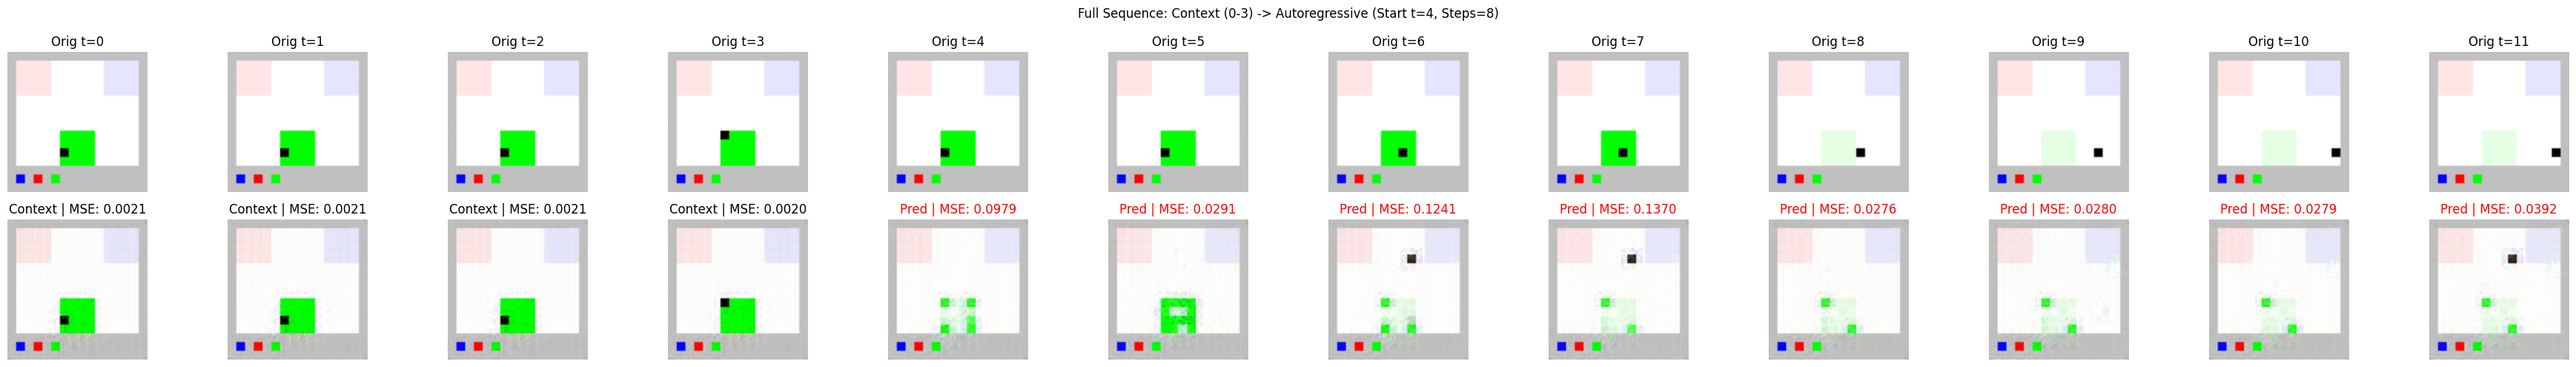

Average MSE over 8 predicted frames: 0.06386


Dynamics Epoch 20: 100%|██████████| 12/12 [00:02<00:00,  5.48it/s, act=1.2177, flow=0.0026, rew=0.1054]


--- Epoch 20 Evaluation ---


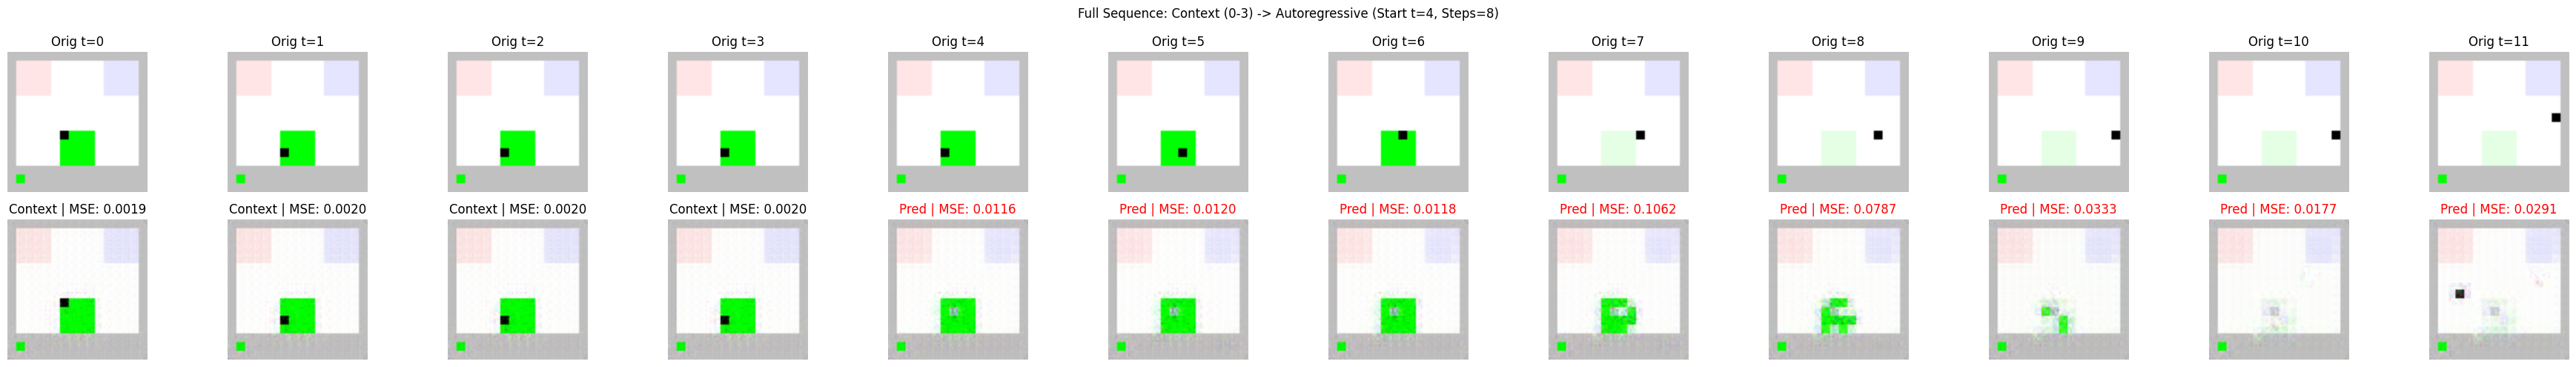

Average MSE over 8 predicted frames: 0.03756


Dynamics Epoch 30: 100%|██████████| 12/12 [00:02<00:00,  5.66it/s, act=1.1979, flow=0.0024, rew=0.1326]


--- Epoch 30 Evaluation ---


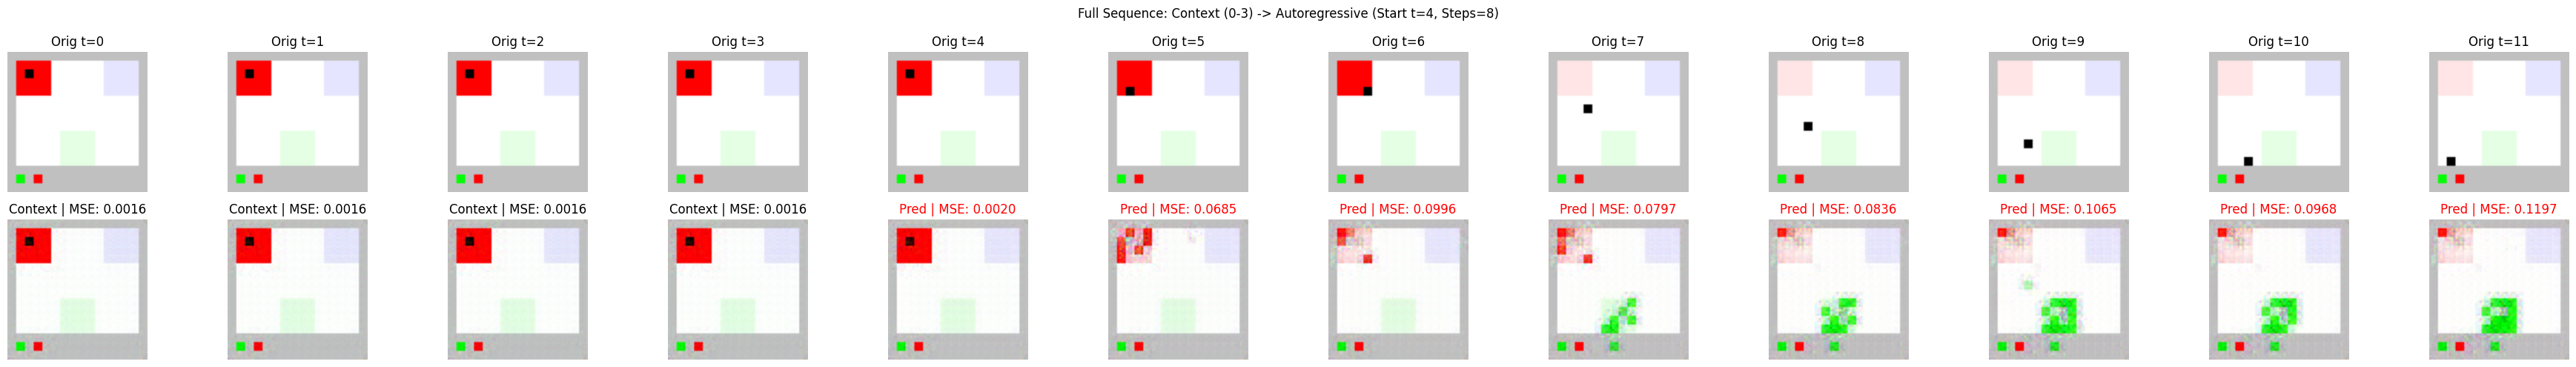

Average MSE over 8 predicted frames: 0.08206


Dynamics Epoch 40: 100%|██████████| 12/12 [00:02<00:00,  5.61it/s, act=1.2096, flow=0.0024, rew=0.1018]


--- Epoch 40 Evaluation ---


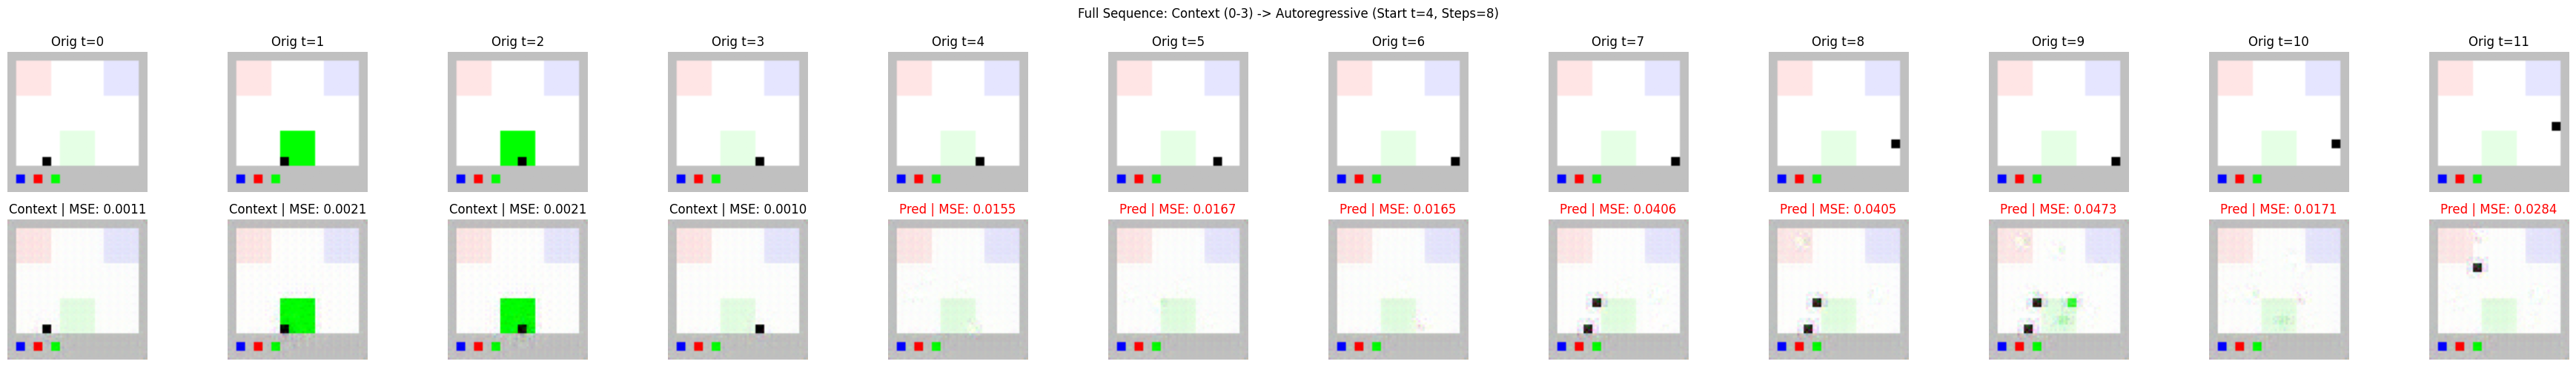

Average MSE over 8 predicted frames: 0.02782


Dynamics Epoch 50: 100%|██████████| 12/12 [00:02<00:00,  5.63it/s, act=1.1959, flow=0.0025, rew=0.0898]


--- Epoch 50 Evaluation ---


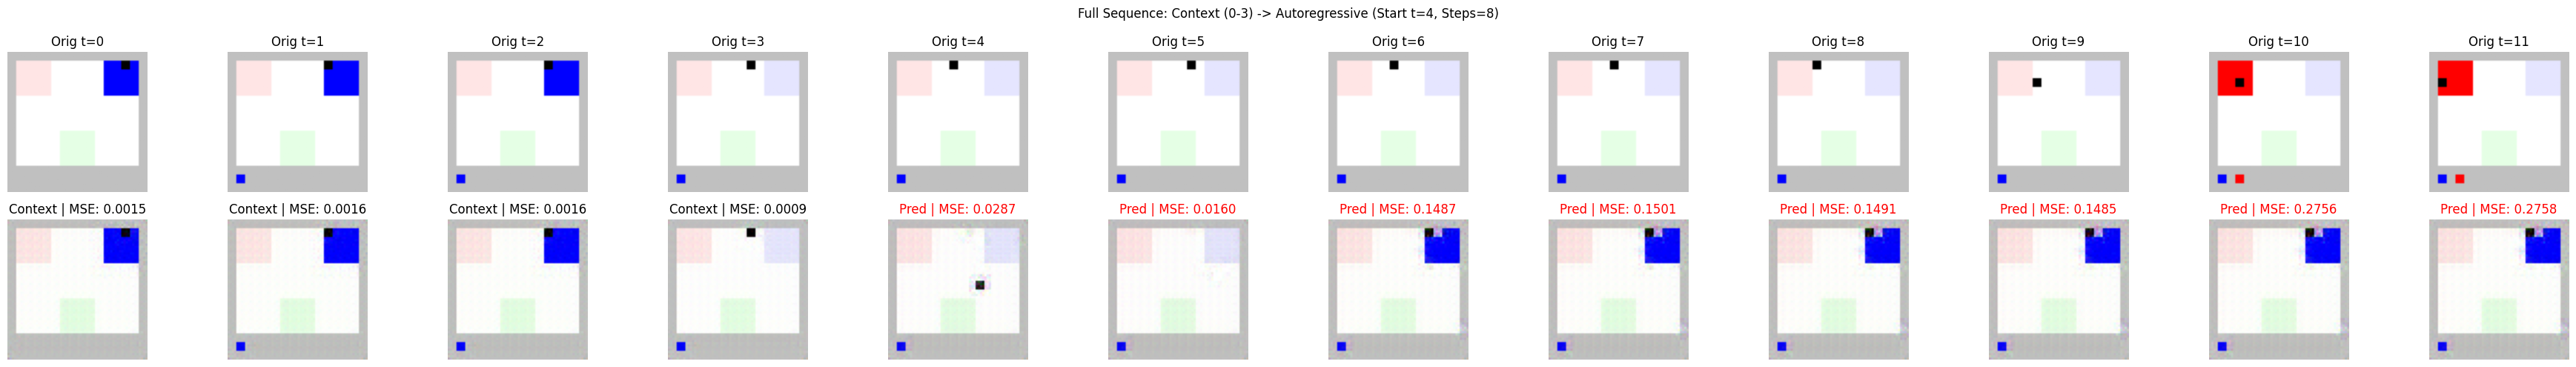

Average MSE over 8 predicted frames: 0.14906


Dynamics Epoch 60: 100%|██████████| 12/12 [00:02<00:00,  5.60it/s, act=1.2153, flow=0.0026, rew=0.0368]


--- Epoch 60 Evaluation ---


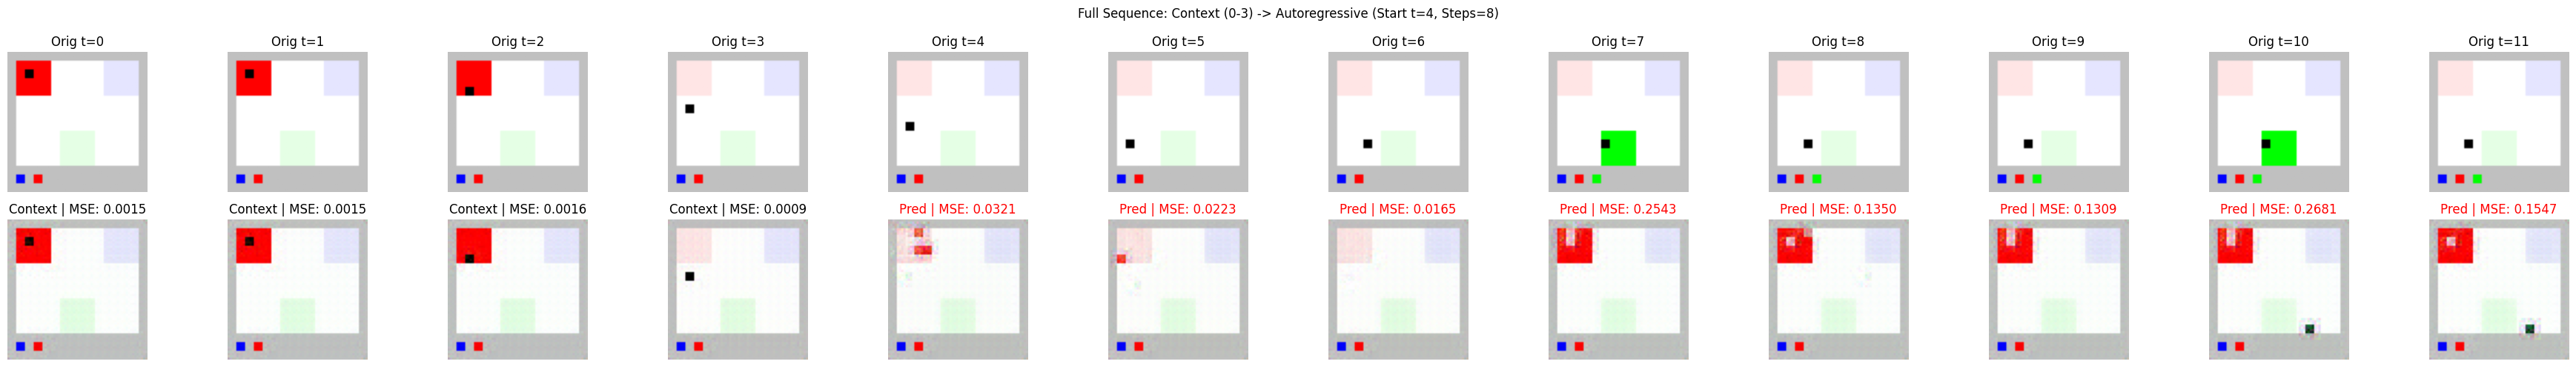

Average MSE over 8 predicted frames: 0.12676


Dynamics Epoch 70: 100%|██████████| 12/12 [00:02<00:00,  5.63it/s, act=1.1896, flow=0.0023, rew=0.0701]


--- Epoch 70 Evaluation ---


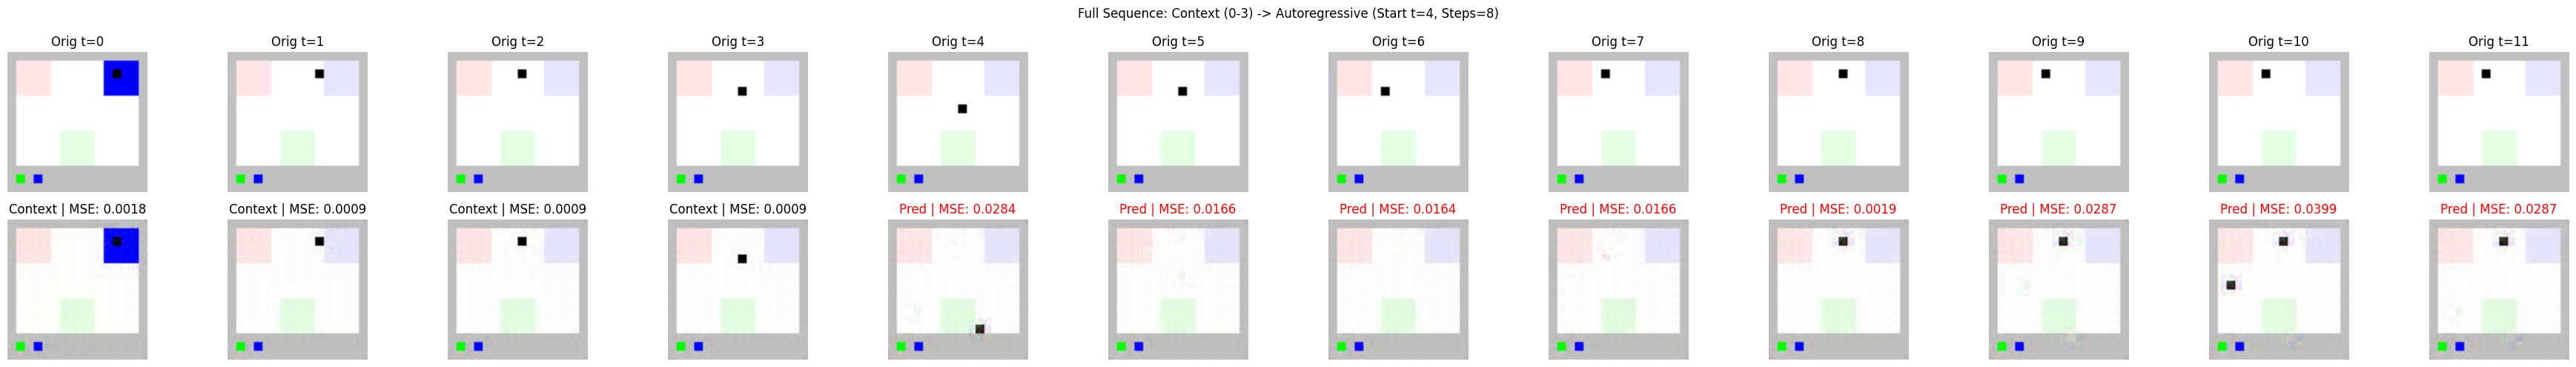

Average MSE over 8 predicted frames: 0.02214


Dynamics Epoch 80: 100%|██████████| 12/12 [00:02<00:00,  5.61it/s, act=1.2183, flow=0.0025, rew=0.0913]


--- Epoch 80 Evaluation ---


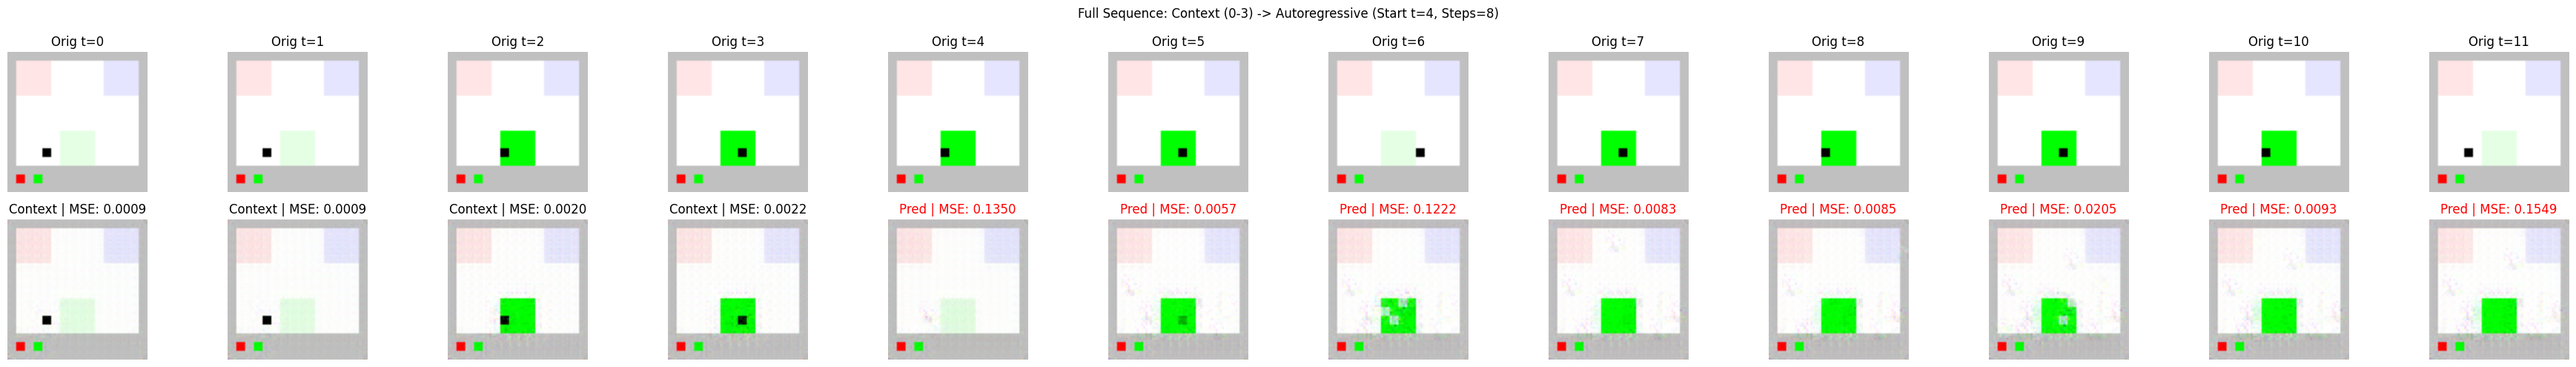

Average MSE over 8 predicted frames: 0.05804


Dynamics Epoch 84:  92%|█████████▏| 11/12 [00:02<00:00,  5.00it/s, act=1.1894, flow=0.0025, rew=0.1210]


KeyboardInterrupt: 

In [53]:
# 1. Setup
print("Training World Model Physics (Reconstruction)...")
dynamics.train()

# Use your existing bc_ds dataset
dl = DataLoader(bc_ds, batch_size=16, shuffle=True, drop_last=True)
epochs = 100 

for epoch in range(epochs):
    epoch_loss = 0
    with tqdm(dl, desc=f"Dynamics Epoch {epoch+1}") as pbar:
        for batch_idx, batch in enumerate(pbar):
            # Prepare Data
            video = batch['video']
            actions = batch['discrete_actions']
            rewards = batch.get('rewards', None) # If your dataset has rewards
            
            # Tokenize
            with torch.no_grad():
                if video.dtype == torch.uint8:
                    video = video.float() / 255.0
                    video = video * 2.0 - 1.0
                target_dtype = next(tk.parameters()).dtype 
                video = video.to(device, dtype=target_dtype)
                latents = tk.tokenize(video)

            actions = actions.to(device)
            
            # [FIX 2] Clamp Rewards to prevent "Value Head Death" scenario
            # Even though this trains the Reward Predictor (not Value Head), 
            # outliers can still destabilize the shared features.
            if rewards is not None:
                rewards = rewards.to(device).clamp(-20, 20)

            # --- DYNAMICS UPDATE ---
            loss, all_losses = dynamics(
                latents=latents,
                discrete_actions=actions,
                rewards=rewards,
                return_pred_only=False, 
                latent_is_noised=False,
                return_all_losses=True,
            )
            
            if isinstance(loss, tuple): loss = loss[0]

            # Update
            dynamics_optim.zero_grad()
            loss.backward()
            
            # Clip grads (Safe)
            torch.nn.utils.clip_grad_norm_(dynamics.parameters(), 0.5)
            
            dynamics_optim.step()
            
            epoch_loss += all_losses.flow.item()

            pbar.set_postfix(
                flow=f"{all_losses.flow.item():.4f}",
                rew=f"{all_losses.rewards.mean().item():.4f}",
                act=f"{all_losses.discrete_actions.mean().item():.4f}"
            )

    # [FIX 1] Visualization INSIDE the loop
    # Check progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"--- Epoch {epoch+1} Evaluation ---")
        
        # Pick a random sample for variety
        sample = bc_ds[random.randint(0, len(bc_ds)-1)]
        video_sample = sample["video"].to(tk.device)
        acts_sample  = sample.get("discrete_actions").to(tk.device)
        
        viz_autoregressive(
            tokenizer=tk,
            dynamics=dynamics,
            video=video_sample,
            discrete_actions=acts_sample,
            start_k=4,   
            n_frames=8, # See if it holds up for 8 frames
            num_steps=8
        )
        
        # Put back in train mode!
        dynamics.train() 

print("Physics Engine Trained.")

In [ ]:
import torch.nn.functional as F

@torch.no_grad()
def get_action_probs(dynamics, video):
    """
    Returns the probability distribution over discrete actions.
    Correctly handles ActionEmbedder's parameter-based projection.
    Returns: (Batch, Time, Num_Actions)
    """
    dynamics.eval()
    
    # 1. Tokenize
    if video.ndim == 4: video = video.unsqueeze(0)
    latents = dynamics.video_tokenizer.tokenize(video)
    
    # 2. Dynamics Forward (Get Agent Embeddings)
    # We pass actions=None so it runs in generation mode (using past context)
    _, (embeds, _) = dynamics(
        latents=latents,
        return_intermediates=True,
        return_pred_only=True
    )
    
    # 3. Get Agent Embeddings
    # Shape: (B, T, Agents, Dim) -> (B, T, Dim)
    # Assuming 1 agent
    if embeds.agent.ndim == 4:
        agent_embeds = embeds.agent.squeeze(2)
    else:
        agent_embeds = embeds.agent
    
    # 4. Policy Head Projection (MLP)
    policy_embed = dynamics.policy_head(agent_embeds)
    
    # 5. [CORRECTED] Extract Logits using the Embedder
    # The embedder has a specific method 'unembed' that handles the projection matrix
    discrete_logits, _ = dynamics.action_embedder.unembed(
        policy_embed,
        pred_head_index=0 # We only care about the immediate next action
    )
    
    # If multiple discrete action types exist, it returns a tuple or split tensor.
    # For a standard gym env, we usually want the first/only one.
    if isinstance(discrete_logits, (tuple, list)):
        discrete_logits = discrete_logits[0]
        
    # 6. Softmax
    probs = F.softmax(discrete_logits, dim=-1)
    
    return probs

import matplotlib.pyplot as plt
import numpy as np

def viz_actor_confidence(dynamics, dataset, idx=0):
    sample = dataset[idx]
    video = sample['video'].to(dynamics.device)
    true_actions = sample['discrete_actions'].cpu().numpy().flatten()
    
    # Get Probabilities
    probs = get_action_probs(dynamics, video)[0].cpu().numpy() # (Time, Num_Actions)
    
    T, N = probs.shape
    time_steps = np.arange(T)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Heatmap
    # Transpose so Time is X-axis
    im = ax.imshow(probs.T, aspect='auto', cmap='viridis', vmin=0, vmax=1, origin='lower')
    
    # Overlay Ground Truth
    # We plot the Expert's choice as a red X
    # Note: Action at step T usually predicts state T+1 or is taken at state T.
    # Check alignment: if the X's lag behind the blue spots, shift by +1.
    ax.scatter(time_steps, true_actions[:T], color='red', marker='x', s=100, linewidth=2, label='Expert Action')
    
    ax.set_title(f"Actor Policy Distribution (Sample {idx})")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Action Class")
    ax.set_yticks(range(N))
    ax.legend(loc='upper right')
    
    fig.colorbar(im, ax=ax, label="P(action|state)")
    plt.tight_layout()
    plt.show()

# Run it on a random sample
import random
idx = random.randint(0, len(bc_ds)-1)
viz_actor_confidence(dynamics, bc_ds, idx)

Searching for logit layer...


UnboundLocalError: local variable 'logit_layer' referenced before assignment

In [47]:
# 1. Freeze the Transformer (Backbone)
for p in dynamics.parameters(): 
    p.requires_grad = False

# 2. Unfreeze BOTH Heads
for p in dynamics.policy_head.parameters(): 
    p.requires_grad = True
    
for p in dynamics.value_head.parameters(): 
    p.requires_grad = True

# 3. Unfreeze Action/Reward Embeddings (Critical for the heads to work)
if hasattr(dynamics, 'action_embedder'):
    for p in dynamics.action_embedder.parameters(): p.requires_grad = True
if hasattr(dynamics, 'reward_encoder'):
    # Usually reward encoder is fixed, but let's check your specific class
    pass

print("Backbone Frozen. Heads Unfrozen.")

def train_heads_offline(self, dataset, epochs=5):
    epochs = default(epochs, self.epochs)
    
    if self.video_tokenizer is None:
        self.video_tokenizer = getattr(self.unwrapped_model, 'video_tokenizer', None)
    
    dl = DataLoader(dataset, batch_size=self.batch_size, shuffle=True, drop_last=True)
    dl = self.accelerator.prepare(dl)

    print(f"Starting Head Warmup (Policy + Value) for {epochs} epochs...")

    for epoch in range(epochs):
        with tqdm(dl, desc=f"Warmup Epoch {epoch+1}/{epochs}") as pbar:
            for batch in pbar:
                # 1. Data
                video = batch['video']
                actions = batch['discrete_actions']
                rewards = batch.get('rewards', None) 

                with torch.no_grad():
                    if video.dtype == torch.uint8:
                        video = video.float() / 255.0
                        video = video * 2.0 - 1.0
                    
                    target_dtype = next(self.video_tokenizer.parameters()).dtype
                    video = video.to(self.device, dtype=target_dtype)
                    latents = self.video_tokenizer.tokenize(video)

                # 2. Forward (Get Embeddings)
                with torch.no_grad():
                    _, (embeds, _) = self.model(
                        latents=latents,
                        discrete_actions=actions, 
                        return_intermediates=True,
                        return_pred_only=True 
                    )
                    agent_embeds = embeds.agent # Shape: (B, T, 1, D)

                # 3. Policy Loss (Behavior Cloning)
                policy_logits = self.model.policy_head(agent_embeds)
                
                # log_probs helper handles the extra dimensions gracefully usually, 
                # but if it fails, we might need to squeeze agent_embeds first.
                # For now, let's trust it works or squeeze if needed:
                if agent_embeds.ndim == 4:
                    policy_logits = policy_logits.squeeze(2) # Remove agent dim (B, T, 1, D) -> (B, T, D)

                log_probs = self.model.action_embedder.log_probs(
                    policy_logits, # Passed as logits, helper will softmax it
                    discrete_targets=actions,
                    pred_head_index=0,
                ) 
                
                # Handle tuple return
                if isinstance(log_probs, tuple):
                    log_probs = log_probs[0]
                    
                policy_loss = -log_probs.mean()

                # 4. Value Loss (Reward Prediction)
                value_loss = torch.tensor(0., device=self.device)
                
                if rewards is not None:
                    rewards = rewards.to(self.device).clamp(-20, 20)
                    
                    # value_bins Shape: (B, T, 1, N_bins) -> because input had agent dim
                    value_bins = self.model.value_head(agent_embeds)
                    
                    # Target Encoding
                    target_bins = self.model.reward_encoder(rewards) 
                    
                    # [FIX] Robust Rearrange
                    # Uses '...' to absorb the agent dimension (whether it exists or not)
                    # Flattens everything into (Batch * Time * Agents, Bins)
                    value_bins_flat = rearrange(value_bins, 'b t ... n -> (b t ...) n')
                    target_bins_flat = rearrange(target_bins, 'b t ... n -> (b t ...) n')
                    
                    value_loss = F.cross_entropy(value_bins_flat, target_bins_flat)

                # 5. Updates
                total_loss = policy_loss + value_loss

                self.accelerator.backward(total_loss)
                
                if exists(self.max_grad_norm):
                    head_params = [
                        *self.model.policy_head.parameters(),
                        *self.model.value_head.parameters()
                    ]
                    self.accelerator.clip_grad_norm_(head_params, self.max_grad_norm)
                
                self.policy_head_optim.step()
                self.value_head_optim.step()
                
                self.policy_head_optim.zero_grad()
                self.value_head_optim.zero_grad()
                
                pbar.set_postfix(pol=policy_loss.item(), val=value_loss.item())

    print("Head Warmup Complete.")

# Monkey Patch
import types
from einops import rearrange
import torch.nn.functional as F

sim_tr.train_heads_offline = types.MethodType(train_heads_offline, sim_tr)

# Run
sim_tr.train_heads_offline(bc_ds, epochs=5)

Backbone Frozen. Heads Unfrozen.
Starting Head Warmup (Policy + Value) for 5 epochs...


Warmup Epoch 5/5: 100%|██████████| 12/12 [00:00<00:00, 13.12it/s, pol=0.671, val=0.106] 

Head Warmup Complete.


In [48]:
# Unfreeze everything
for p in dynamics.parameters(): p.requires_grad = True
print("All systems go. Ready for Online PPO.")

All systems go. Ready for Online PPO.


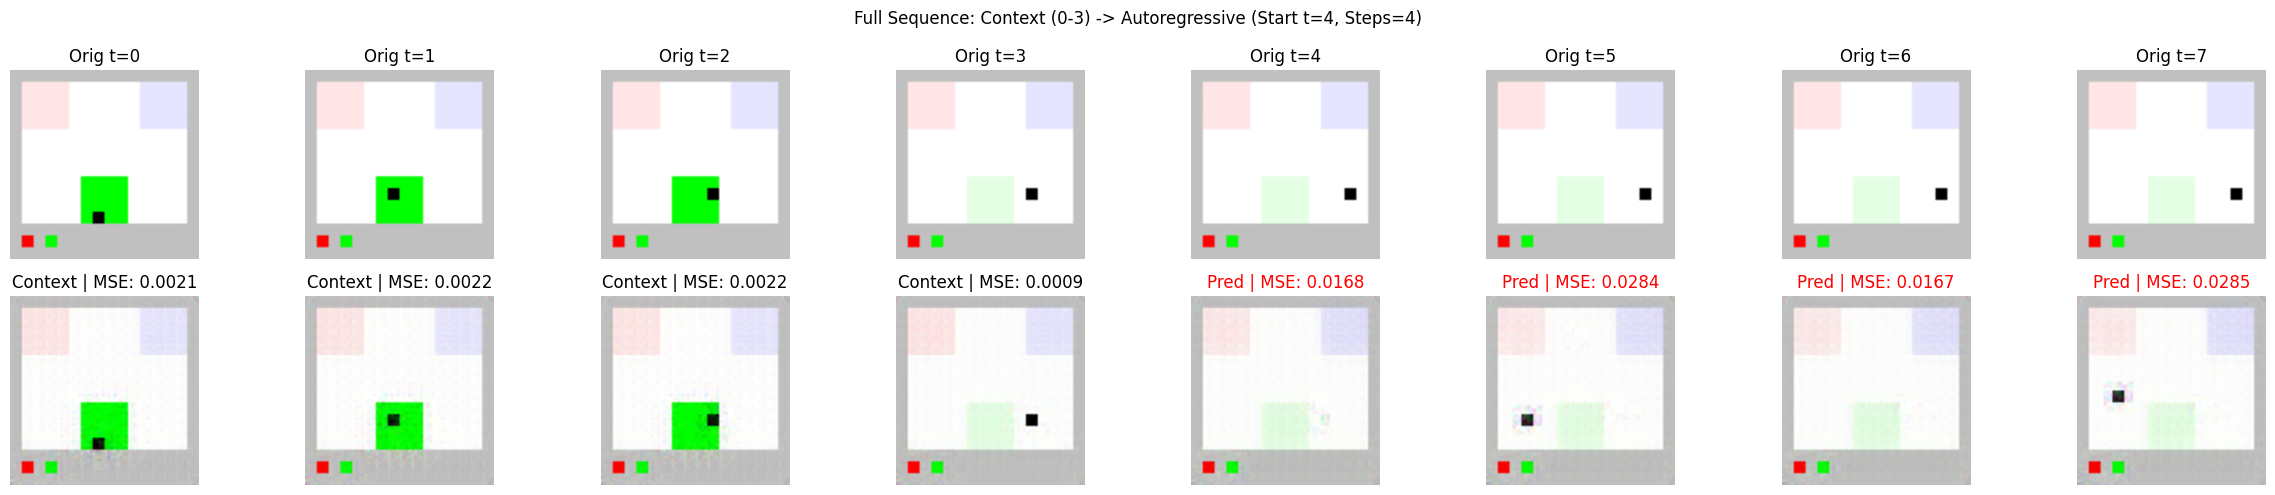

Average MSE over 4 predicted frames: 0.02257
Physics Engine Trained.
flow 0.0024490393698215485
rewards tensor([0.1230, 0.1297, 0.1490, 0.1595, 0.1624, 0.1381, 0.1155, 0.1013],
       device='cuda:0', grad_fn=<MeanBackward1>)
discrete_actions tensor([1.5818, 1.4721, 1.3722, 1.2653, 1.1647, 1.0645, 0.9615, 0.8521],
       device='cuda:0', grad_fn=<MeanBackward1>)
continuous_actions 0.0
state_pred 0.0


In [49]:


sample = bc_ds[random.randint(0, len(bc_ds)-1)]
# ... (your existing data loading code) ...
video = sample["video"].to(tk.device)
acts  = sample.get("discrete_actions").to(tk.device)
# Visualize next 4 frames
viz_autoregressive(
    tokenizer=tk,
    dynamics=dynamics,
    video=video,
    discrete_actions=acts,
    start_k=4,   # Start predicting from frame 4
    n_frames=4,  # Predict 4, 5, 6, 7
    num_steps=8
)
print("Physics Engine Trained.")

for k,v in all_losses._asdict().items():
    print(k,f'{v}')

In [51]:
train_eps=10
dynamics.train()
# experience = dynamics.interact_with_env(env) # one episode
# sim_tr.learn(experience)

sim_tr(env, num_episodes=train_eps, max_env_steps=50)


Agent Embed Norm (Input to Model): 16.0000
policy: -0.0509 | value: 9.0897
Agent Embed Norm: 323.1841
Checked first batch and found grads.

--- VALUE HEAD DIAGNOSTICS ---
Rewards Range: 0.0000 to 1.0000
Loss Requires Grad: True
Total Grad Norm: 33.721252
Weight Sample: 1.002333 (Watch if this changes!)
Current LR: 0.000300
------------------------------

Action Embed Grad Norm: 0.011619
Spatial Embed Grad Norm: 0.011752
Agent Embed Norm (Input to Model): 16.0000
policy: -0.0542 | value: 7.2445
Agent Embed Norm: 323.1841
Checked first batch and found grads.

--- VALUE HEAD DIAGNOSTICS ---
Rewards Range: 0.0000 to 1.0000
Loss Requires Grad: True
Total Grad Norm: 31.769068
Weight Sample: 1.002463 (Watch if this changes!)
Current LR: 0.000300
------------------------------

Action Embed Grad Norm: 0.011619
Spatial Embed Grad Norm: 0.011752
Agent Embed Norm (Input to Model): 16.0000
policy: -0.0502 | value: 5.2379
Agent Embed Norm: 323.1841
Checked first batch and found grads.

--- VALUE HE

[Eval] Episode 0: total reward = 1.00


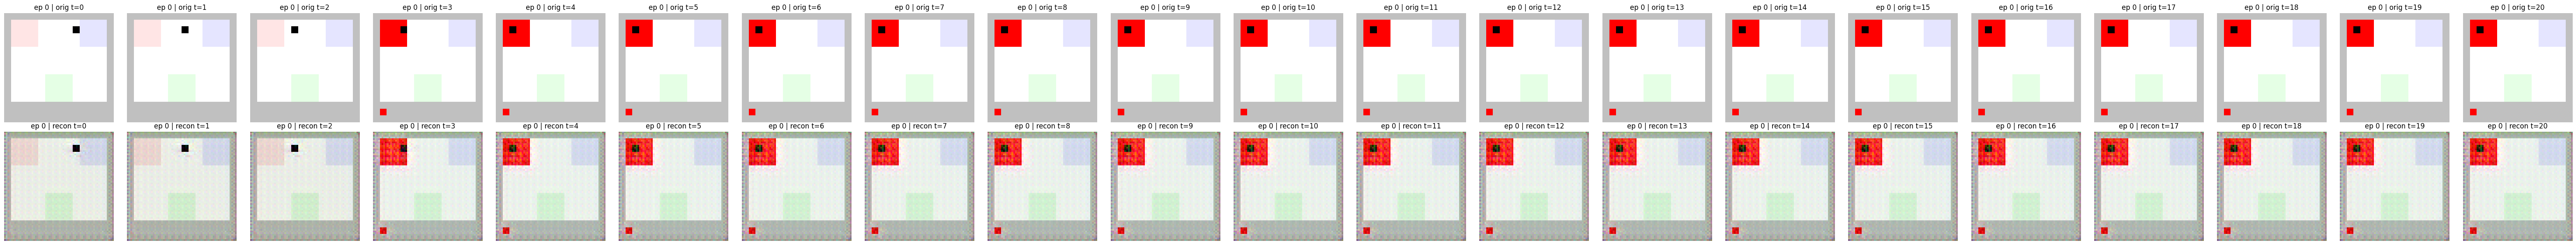

[Eval] Episode 1: total reward = 0.00


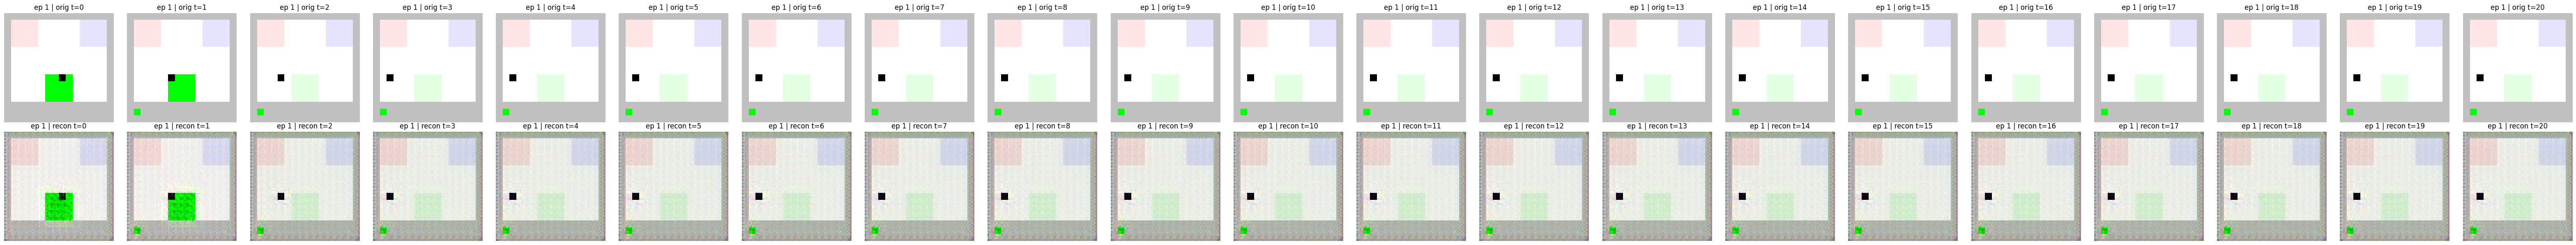

[Eval] Episode 2: total reward = 0.00


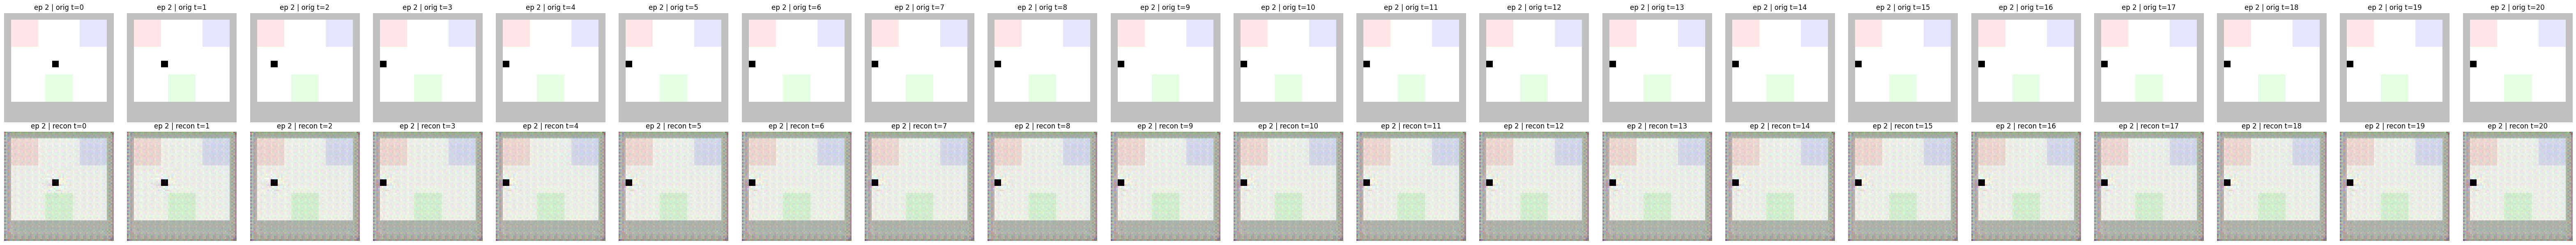

[Experience(latents=tensor([[[[ 0.9322, -1.6679,  0.1034,  ..., -0.6260,  0.1892, -0.8791],
           [ 1.3145, -1.8510,  0.1134,  ..., -0.7112, -0.0593, -0.8738],
           [ 1.2966, -1.8392,  0.1610,  ..., -0.6704, -0.0579, -0.8404],
           ...,
           [ 1.7093, -2.1784,  0.7601,  ..., -1.2715,  0.6318, -0.1240],
           [ 1.7093, -2.1784,  0.7601,  ..., -1.2715,  0.6318, -0.1240],
           [ 1.1879, -1.7488,  0.3563,  ..., -1.5732,  0.3329,  0.0095]],
 
          [[ 0.9321, -1.6676,  0.1034,  ..., -0.6257,  0.1892, -0.8796],
           [ 1.3145, -1.8507,  0.1132,  ..., -0.7110, -0.0593, -0.8742],
           [ 1.2965, -1.8390,  0.1609,  ..., -0.6702, -0.0579, -0.8408],
           ...,
           [ 1.7092, -2.1780,  0.7600,  ..., -1.2712,  0.6317, -0.1243],
           [ 1.7092, -2.1780,  0.7600,  ..., -1.2712,  0.6317, -0.1243],
           [ 1.1878, -1.7482,  0.3564,  ..., -1.5727,  0.3328,  0.0092]],
 
          [[ 0.9320, -1.6676,  0.1035,  ..., -0.6257,  0.1892, -0.8

In [52]:

sim_tr.eval_episodes(env, show=True, max_steps=21, max_time_to_show=21)


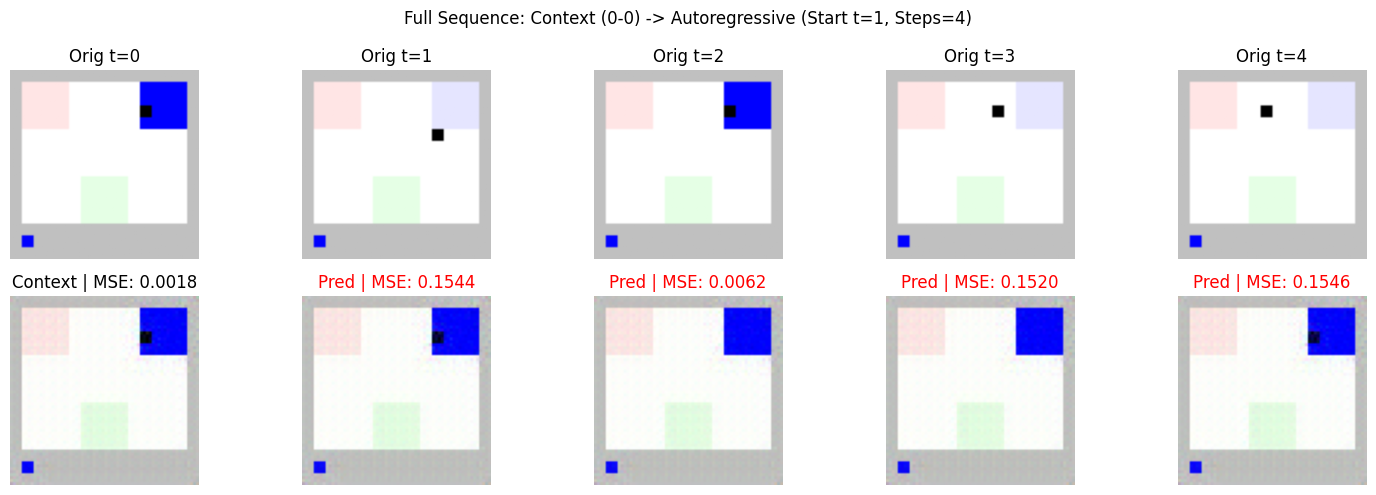

Average MSE over 4 predicted frames: 0.11682


In [26]:

sample = bc_ds[random.randint(0, len(bc_ds)-1)]
# ... (your existing data loading code) ...
video = sample["video"].to(tk.device)
acts  = sample.get("discrete_actions").to(tk.device)
# Visualize next 4 frames
viz_autoregressive(
    tokenizer=tk,
    dynamics=dynamics,
    video=video,
    discrete_actions=acts,
    start_k=1,   # Start predicting from frame 4
    n_frames=4,  # Predict 4, 5, 6, 7
    num_steps=8
)

In [ ]:

"""
Trains the policy head using Behavior Cloning on an existing dataset.
Useful for pre-training before starting online RL.
"""
epochs = 10; train_eps=10
dynamics.train()
# experience = dynamics.interact_with_env(env) # one episode
# sim_tr.learn(experience)

sim_tr.train_from_dataset(bc_ds, epochs)
sim_tr(env, num_episodes=train_eps, max_env_steps=100)
# sim_tr.eval_episodes(env, show=True, max_steps=21, max_time_to_show=21)

sample = bc_ds[random.randint(0, len(bc_ds)-1)]
# ... (your existing data loading code) ...
video = sample["video"].to(tk.device)
acts  = sample.get("discrete_actions").to(tk.device)

# Visualize next 4 frames
viz_autoregressive(
    tokenizer=tk,
    dynamics=dynamics,
    video=video,
    discrete_actions=acts,
    start_k=1,   # Start predicting from frame 4
    n_frames=4,  # Predict 4, 5, 6, 7
    num_steps=8
)



In [ ]:
# plot the losses
import matplotlib.pyplot as plt
import itertools
flat_list = [
    x
    for xs in losses
    for x in xs
]

plt.plot(flat_list)
plt.show()

In [ ]:
if DO_PLOT:=True:
    # quick plot
    plt.figure(figsize=(5,3))
    plt.plot(range(1, H+1), mets["per_step_mse"], marker="o")
    plt.xlabel("Prediction step (t = k + step)")
    plt.ylabel("MSE")
    plt.title(f"Open-loop {H}-step MSE (k={k})")
    plt.tight_layout(); plt.show(block=False)

    # assuming you already have:
    # env          = PinPad(...) or your wrapped env (normalizes to [0,1])
    # tokenizer    = VideoTokenizer(...); tokenizer.eval()
    # dynamics     = DynamicsWorldModel(..., video_tokenizer=tokenizer, ...); dynamics.eval()
    # (optionally load weights for both)


In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()